# LSN-1.5 — Conversational Deep Learning: NN, CNN, RL

| | |
|---|---|
| **Lesson** | `LSN-1.5` — Module `MOD-1` (ML Literacy), Weeks 1–2 |
| **Serves** | `OUT-1.5` — *hold a conversational-level exchange on neural nets, CNNs, deep learning and reinforcement learning* |
| **Duration** | 60 min session (15 + 15 + 15 recorded · 15 live Q&A + pair drill) + 30 min pre-work |
| **Verified by** | `ASM-1` — the live mock pre-sales conversation (Vlad or Dorel plays the client) |
| **Homework** | **None.** The pair drill *is* the rehearsal; keep your four sentences, revised with your partner's scores |
| **Lesson plan** | `program/lessons/LSN-1.5-conversational-deep-learning.md` |

**The bar, in the sponsor's words.** Vlad scoped this whole module around one sentence: *"to know what a neural
network is, what a convolutional neural network is, what deep learning is, what reinforcement learning is — to
have a mini conversation about this and not look completely stupid."* Four terms. Two plain-language minutes
each. That is the entire outcome, and the drill at the end of this notebook is the rehearsal for the `ASM-1`
conversation that grades it.

**Why you are not learning what a neural network is from a slide.** You trained one. Last session, in
`LSN-1.4`, you built a 101,770-parameter network, watched its loss fall from **2.31 to 0.26** in a quarter of a
second, got **92.77%** on 10,000 digits it had never seen, read your own confusion matrix, and computed one
forward pass by hand. **This hour does not teach you a new thing. It gives you the words for the thing you
already did** — and then two more architectures (CNN, RL) that are variations on the same story.

**What this notebook is.** Not a lab — there is no checkpoint battery and nothing here takes longer than a
couple of seconds to run. It is three things:

1. **your pre-work** — the one-page cheat sheet (below), the Karpathy excerpt instruction, and the cell where
   you draft your four sentences *before* the session;
2. **the companion to the recorded talk** — four small live demos that make the vocabulary physical: one
   neuron's arithmetic done by hand, a 3×3 filter slid over the digit *you* pushed through your own network
   last session, and a Q-learning agent that learns a route and then — when the reward is written down badly —
   learns to cheat instead;
3. **the drill workspace** — the four client prompts verbatim, the peer-grading rubric verbatim, and the cells
   where your sentences and your partner's scores get written down and saved.

### The four terms, on one screen *(the long version is the cheat sheet, two cells down)*

| Term | The one-sentence version | The honest boundary |
|---|---|---|
| **Neural network (NN)** | Layers of weighted sums with a squash in between; "training" is nudging the weights until the outputs match the labels | It learns patterns in labelled examples. No labels, no model — and it fails on anything unlike them |
| **Convolutional neural net (CNN)** | The same idea for images: one small pattern detector, slid across the whole picture, stacked into edges → shapes → objects | Needs a lot of labelled images and consistent framing; 200 photos is a labelling project, not a model |
| **Deep learning (DL)** | A neural network with several layers — deep enough that it works out its own features instead of being handed them | Real, not magic: hungrier for data than shallow models and harder to explain when it's wrong |
| **Reinforcement learning (RL)** | No labels at all — an agent acts, gets a reward, and adjusts; it learns from consequences | Needs somewhere safe and cheap to fail millions of times (a simulator) **and** a reward you can actually write down |

### How to run this

1. Kernel: the repo `.venv` (Python 3.12). From the repo root:
   `.venv/bin/jupyter notebook notebooks/lessons/LSN-1.5_Conversational_Deep_Learning.ipynb`
2. `Run → Run All Cells`. **Total runtime is a few seconds** — nothing here trains anything big; the heavy
   training happened in `LSN-1.4`. Every number this notebook prints, it computed.
3. Fill in the three cells that ask you to: **pre-work** (before the session), and the **drill** cells (during
   the live 15 minutes). They never crash when empty — they tell you what is still missing.
4. Your saved answers land in `outputs/lsn-1.5/`, which is gitignored. They stay on your machine.

## Setup — imports, palette, and the four rules this notebook obeys

- **Everything is seeded and everything is CPU.** The Q-learning agent, the tiny classifier, the train/test
  split: all pinned (`SI-3`). Two executions of this notebook produce byte-identical output, which is the only
  way a committed notebook can be trusted as a reference.
- **The demos are props, deliberately tiny.** A 4-input network you can check on paper, 600 points in two
  rings, a 5×5 grid. Nothing here is evidence that any model works — `LSN-1.3` owns "is it any good?" and
  `LSN-1.4` was the real training run. These exist so that the words you say to a client point at something you
  have seen move.
- **No torch training in this notebook.** `torchvision` is imported for one job only — reading the *same*
  MNIST cache your lab used, so the digit in the CNN segment is literally the digit you already met. The
  convolution itself is nine lines of numpy, because the whole point of the segment is that there is no magic
  in it.
- **No transformers, no LLM libraries** (`SI-24a`). The RLHF beat at the end of segment 3 is a teaser for
  `MOD-2`, told in words. Nothing in this notebook talks to a language model.

In [1]:
# numpy (every demo in this notebook: the tiny network, the convolution, the Q-table)
import numpy as np
# pandas (the parameter-count comparison and the learning-signal table are tables)
import pandas as pd
# matplotlib (four figures: squash + loss curve, decision boundaries, feature maps, RL curves)
import matplotlib.pyplot as plt
# scikit-learn: two three-line props for the "learns its own features" demo (SI-24)
import sklearn
from sklearn.datasets import make_circles
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
# torch / torchvision: used ONLY to read the pre-warmed MNIST cache (SI-24b) - we train nothing here.
# Pinned to CPU on principle (SI-27a) even though no gradient is computed in this notebook.
import torch
from torchvision import datasets
# stdlib re (word-boundary probes for the drill advisor - LL-30: "risk" must not match "brisk")
import re
# stdlib textwrap (the answer key and the advisor print wrapped paragraphs, not 200-char lines)
import textwrap
# stdlib json / getpass / datetime (the two artifacts this notebook saves to outputs/)
import json
import getpass
from datetime import datetime, timezone
# stdlib pathlib (locate the repo root and the dataset cache without hardcoding paths - SI-5)
from pathlib import Path

# --- VSP palette. Four data colours from the design system + one ink colour for reference
# --- lines, cell edges and annotation text (VSP navy-darkest), plus two darker tints used
# --- only for annotation text that must stay readable at projector size.
VSP = {
    "navy":   "#59709c",  # navy-light      - the plain / baseline series
    "green":  "#65a74e",  # green           - anything that worked
    "yellow": "#ffe86b",  # yellow          - anything highlighted
    "mint":   "#97f377",  # green-lightest  - third series
    "ink":    "#2b374d",  # navy-darkest    - lines, edges, text
    "green_dark": "#4f813e",
    "gold_dark":  "#d9b800",
}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.edgecolor": VSP["ink"],
    "axes.labelcolor": VSP["ink"],
    "text.color": VSP["ink"],
    "xtick.color": VSP["ink"],
    "ytick.color": VSP["ink"],
    "legend.frameon": False,
})
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 24)


def find_repo_root(start: Path) -> Path:
    """Walk up from `start` to the directory holding src/ and README.md (mirrors src/utils/pathing.py)."""
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src").is_dir() and (candidate / "README.md").is_file():
            return candidate
    raise ValueError("Repo root not found - are you running inside the VSP-AI-ML-Training clone?")


REPO_ROOT = find_repo_root(Path.cwd())
OUT_DIR = REPO_ROOT / "outputs" / "lsn-1.5"                # gitignored via outputs/lsn-*/ (SI-4)
DATA_ROOT = Path.home() / ".cache" / "vsp-training-data"    # OUTSIDE the repo, on purpose (SI-24b)

# ---------------------------------------------------------------- the pins
DEVICE = "cpu"        # pinned (SI-27a). Nothing trains in torch here; the pin is the house rule.
SEED = 15_042         # one seed for the whole lesson: lesson 1.5, run 042
torch.manual_seed(SEED)
np.random.seed(SEED)  # belt and braces; every draw below uses its own explicit generator

# ---- the LSN-1.4 numbers this lesson speaks in. Every one of them is quoted from that notebook's
#      executed output, not remembered - see the "your own numbers" table in segment 1.
LAB = {
    "params": 101_770,      # 784*128 + 128 + 128*10 + 10
    "n_train": 10_000,      # the lab subset
    "epochs": 3,
    "steps": 471,           # gradient steps = 157 batches x 3 epochs
    "loss_first": 2.3117,   # first batch, before any weight moved (~ln 10 = 2.3026)
    "loss_epochs": (0.7554, 0.3195, 0.2585),
    "test_acc": 0.9277,     # 10,000 held-out digits
    "full_acc": 0.9704,     # the same architecture on all 60,000
    "acc_200": 0.6441,      # 200 labelled examples, 3 epochs - the construction prospect's number
    "acc_200_equal": 0.8290,  # 200 examples trained to equal compute (~471 steps)
    "acc_100_equal": 0.7563,  # 100 examples, 40x the training - "you can't buy your way out"
    "worst_pair": (3, 5, 66),  # 3<->5, 66 mistakes both directions
}
COMPOUND_5 = LAB["test_acc"] ** 5      # the 5-digit invoice beat from LSN-1.4


# ---------------------------------------------------------------- shared helpers
def wrap(label: str, text: str, width: int = 104, pad: int = 12) -> None:
    """Print `label` + wrapped `text` in the answer-key idiom used across this programme."""
    print(textwrap.fill(text, width=width, initial_indent=f"  {label:<{pad - 2}}",
                        subsequent_indent=" " * pad))


def _probe_regex(pattern: str) -> str:
    """A pattern ending in '*' matches a word STEM; otherwise it must match a whole word/phrase.

    LL-30: naive substring probes fire on the wrong words - "risk" inside "brisk", "only"
    inside "commonly". Word boundaries fix it.
    """
    p = pattern.strip().lower()
    stem = p.endswith("*")
    if stem:
        p = p[:-1]
    body = r"\s+".join(re.escape(w) for w in p.split())
    return r"\b" + body + ("" if stem else r"\b")


def probe(text, patterns) -> list:
    """Which of `patterns` appear in `text`, matched on word boundaries."""
    t = " ".join(str(text).lower().split())
    return [p for p in patterns if re.search(_probe_regex(p), t)]


def probe_spans(text, patterns) -> list:
    """The DISTINCT words of `text` that any pattern matched (LL-35: count words, not patterns)."""
    t = " ".join(str(text).lower().split())
    raw = sorted({(m.start(), m.end()) for p in patterns
                  for m in re.finditer(_probe_regex(p), t)}, key=lambda s: (s[0], -s[1]))
    words, end = [], -1
    for a, b in raw:
        if a >= end:
            words.append(t[a:b])
        end = max(end, b)
    return words


def show(frame: pd.DataFrame) -> None:
    """Display a PLAIN DataFrame.

    Deliberately NOT `DataFrame.style`: a Styler stamps a random uuid into its HTML and a live
    memory address into its text/plain repr, so two executions of this notebook would differ
    byte-for-byte for no reason at all (LL-33). Formatting happens before the frame is built.
    """
    display(frame)


def save_artifact(name: str, payload: dict) -> Path:
    """Write one gitignored per-participant artifact and return its path (SI-4)."""
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    path = OUT_DIR / f"{name}_{getpass.getuser()}.json"
    path.write_text(json.dumps({"lesson": "LSN-1.5", "serves": ["OUT-1.5"], "assessment": "ASM-1",
                                "user": getpass.getuser(),
                                "timestamp_utc": datetime.now(timezone.utc)
                                .strftime("%Y-%m-%d %H:%M UTC"), **payload}, indent=2))
    return path


# --- Self-tests on the probe helpers. Every one of these is a real false positive that
#     word-boundary matching prevents (LL-30/LL-35) - including the programme's own phrase.
assert probe("walk at a brisk pace", ["risk*"]) == []
assert probe("this carries real risks", ["risk*"]) == ["risk*"]
assert probe("commonly misread", ["only"]) == []
assert probe("only labelled photos", ["only", "label*"]) == ["only", "label*"]
assert probe_spans("needs data, needs labels", ["need*", "needs"]) == ["needs", "needs"]

print(f"numpy {np.__version__}  ·  pandas {pd.__version__}  ·  "
      f"matplotlib {plt.matplotlib.__version__}  ·  scikit-learn {sklearn.__version__}")
print(f"torch {torch.__version__}   <- imported to READ the MNIST cache; nothing is trained in torch here")
print(f"device     : {DEVICE}   <- pinned (SI-27a)")
print(f"seed       : {SEED}")
print(f"Repo root  : {REPO_ROOT}")
print(f"Dataset    : {DATA_ROOT}   <- OUTSIDE the repo (SI-24b)")
print(f"Artifacts  : outputs/lsn-1.5/  (created on first save; gitignored)")
print(f"LSN-1.4 numbers loaded: {LAB['params']:,} parameters, {LAB['test_acc']:.2%} test accuracy, "
      f"loss {LAB['loss_first']:.2f} -> {LAB['loss_epochs'][-1]:.2f}")
print("[PASS] Setup complete - palette loaded, paths resolved, seeds pinned, probe self-tests green.")

numpy 2.5.1  ·  pandas 3.0.5  ·  matplotlib 3.11.1  ·  scikit-learn 1.9.0
torch 2.13.0   <- imported to READ the MNIST cache; nothing is trained in torch here
device     : cpu   <- pinned (SI-27a)
seed       : 15042
Repo root  : /Users/tylergoble/Desktop/VSP Github/tylergoble-VSP/VSP-AI-ML-Training
Dataset    : /Users/tylergoble/.cache/vsp-training-data   <- OUTSIDE the repo (SI-24b)
Artifacts  : outputs/lsn-1.5/  (created on first save; gitignored)
LSN-1.4 numbers loaded: 101,770 parameters, 92.77% test accuracy, loss 2.31 -> 0.26
[PASS] Setup complete - palette loaded, paths resolved, seeds pinned, probe self-tests green.


---

# Pre-work — do this **before** the session

*30 minutes total. Mandatory: no pre-work, no seat.*

| # | Task | Time | What to bring |
|---|---|---|---|
| 1 | Watch the curated **~15-min excerpt** from Andrej Karpathy, *["The spelled-out intro to neural networks and backpropagation: building micrograd"](https://www.youtube.com/watch?v=VMj-3S1tku0)* (Neural Networks: Zero to Hero) | 15 min | **One question** the excerpt left you with |
| 2 | Read the **one-page NN/CNN/DL/RL cheat sheet** — the next two cells of this notebook | 10 min | Nothing to submit |
| 3 | Draft **one client-safe sentence for each of the four terms** | 5 min | Your four sentences — raw material for the pair drill |

### Task 1 — the Karpathy excerpt

**Source:** Andrej Karpathy, *["The spelled-out intro to neural networks and backpropagation: building
micrograd"](https://www.youtube.com/watch?v=VMj-3S1tku0)*, from the **Neural Networks: Zero to Hero** series (YouTube, free). The full video is over two
hours; **you are watching about fifteen minutes of it.**

> **`[TODO — delivery prep]` Excerpt timestamps.** The lesson plan leaves the exact clip to delivery prep, and
> this notebook will not invent timestamps it has not checked. Tyler pins the start/stop before the session and
> posts them with the calendar invite.
>
> **Candidate excerpt (UNVERIFIED — confirm at delivery prep):** the opening stretch, in which Karpathy
> introduces a derivative as "which way and how much does the output move if I nudge this input", and pushes
> one tiny expression forward and backward by hand. That is the 15 minutes that pays off in this lesson,
> because *"nudge the input and see which way the output moves"* is exactly what `optimizer.step()` did to all
> 101,770 of your weights last session.

**What to bring:** one written question. Not "I didn't understand it" — one specific thing. It gets answered in
the live 5-minute Q&A, and the questions people bring are the best signal we get about what the recording
missed.

**Optional, if the excerpt leaves you wanting the picture rather than the code:** 3Blue1Brown, *["But what is a
neural network?"](https://www.youtube.com/watch?v=aircAruvnKk)* (Deep Learning, chapter 1).

### Task 2 — the cheat sheet, and where it lives

The lesson plan's Materials table lists the one-page cheat sheet as a **build** item ("distill from deck +
notebooks at delivery prep"). **It is built, and it is the next two cells of this notebook** — that is its
canonical home. Read it; there is nothing to submit.

**On the source deck.** The plan points at Tyler's original *ML literacy deck* (`PROGRAM_PLAN.md` §8), which is
**not in this repo** — the same call `LSN-0.4`, `LSN-1.1` and `LSN-1.2` made (`SI-25`). So: the original deck is
cited as the source, and the content is carried here and in `program/lessons/decks/LSN-1.5-conversational-deep-learning.html`,
which is the canonical deck for this lesson. Don't go hunting for a file.

### Task 3 — four sentences, drafted badly on purpose

Write them **before** you watch anything, in the cell below. Four sentences, one per term, the way you would
say them to a client who is not an engineer. They will be clumsy, and that is the point: the drill compares
these against the versions you write *after* the session, and the delta is what this hour bought you.

---

## 📄 The one-page cheat sheet — NN · CNN · DL · RL

*Pre-work task 2. This is the canonical cheat sheet for `LSN-1.5`. Distilled from the three reference notebooks'
intros (`notebooks/neural_networks/01`, `notebooks/neural_networks/02`, `notebooks/reinforcement/01`), the
`LSN-1.4` lab you ran, and Tyler's original ML literacy deck (source; not in this repo — `SI-25`).*

### 1 · Neural network (NN)

| | |
|---|---|
| **What it is** | Layers of neurons. One neuron = multiply each input by a weight, add them up, add a bias, then **squash** the result through a simple function (`ReLU`: negatives become zero). A layer is a set of those. A network is layers feeding layers. |
| **What "training" is** | Show it examples, compare its output to the right answer, compute how wrong it was (the **loss**), nudge every weight a hair in the direction that reduces the loss, repeat. Your lab did that 471 times in a quarter of a second. |
| **Takes in** | A row of numbers. An image becomes a row: `28 × 28 = 784` pixel brightnesses. |
| **Kicks out** | One score per possible answer (**logits**) → the biggest one is the prediction; `softmax` turns the scores into probabilities (`LSN-1.2`). |
| **The plain-language line** | *"It's a stack of very simple arithmetic — weighted sums with a squash in between — and 'training' means nudging those weights until its guesses match the labels."* |
| **Honest boundary** | It learns patterns **in the labelled examples it was shown**. No labels, no model. It does not know why, it does not understand, and it fails on inputs unlike its training data. |
| **You have already met it** | `LSN-1.4`: 784 → 128 → 10, **101,770 parameters**, loss **2.31 → 0.26**, **92.77%** on 10,000 unseen digits. |
| **Source notebook** | `notebooks/neural_networks/01_NeuralNetworks_Perceptron_MLP.ipynb` — the perceptron, the MLP, learning curves, architecture comparison. |

### 2 · Convolutional neural network (CNN)

| | |
|---|---|
| **What it is** | A neural network built for grid-shaped data. Instead of one weight per pixel per neuron, it learns a **small filter** (e.g. 3×3 = nine weights) and **slides it across the whole image**, producing a map of "where did this pattern fire?". |
| **Why not a plain network** | **Reuse** — one edge detector works everywhere in the frame, so you learn nine numbers instead of one per position. **Locality** — a 3×3 window knows that neighbouring pixels are related; a flat 784-number row does not. |
| **How depth works** | Stack the layers: filters on pixels find **edges**; filters on edge-maps find **corners and textures**; filters on those find **shapes**; the top of the stack finds **objects**. Pooling shrinks the maps between layers so later filters see more of the picture at once. |
| **Takes in** | The image as a grid (`1 × 28 × 28`), not a flat row — the shape is the whole point. |
| **Kicks out** | Same as any classifier: one score per class. (Detection models also emit boxes; same machinery.) |
| **The plain-language line** | *"It learns one small pattern detector and slides it over the whole picture, then stacks detectors — edges into shapes into objects. That's why it beats a normal network on photos: the same detector works anywhere in the frame."* |
| **Honest boundary** | Hungry: needs **many labelled images**, and it is sensitive to framing, lighting and camera position. `LSN-1.4` priced this — **200 labelled examples bought 64.41%** on clean, centred digits. Real site photos are harder. |
| **Where you'll meet it** | The construction-site photo/video prospect. Any "is it done / is it there / is it damaged" question about images. |
| **Source notebook** | `notebooks/neural_networks/02_NeuralNetworks_Convolutional_Neural_Networks.ipynb` — `Conv2d`, pooling, feature-map visualisation. (See the go-deeper table at the end: it downloads MNIST over the network and ships no saved outputs.) |

### 3 · Deep learning (DL)

| | |
|---|---|
| **What it is** | Not a different family — a **depth** claim. A neural network with several layers between input and output is "deep". That is the whole etymology. |
| **What depth buys** | **Learned features.** A shallow model needs a human to engineer the useful columns; a deep one composes its own out of the raw input. Nobody told your MNIST model what a stroke or a loop is — it got 784 raw pixels. |
| **Where it sits** | `LSN-1.1`'s nesting doll: **AI ⊃ machine learning ⊃ deep learning ⊃ generative AI.** Deep learning is a *subset* of ML, and today's LLMs (`MOD-2`) are a subset of deep learning. |
| **The plain-language line** | *"Deep learning is machine learning where the model is a neural network with several layers. What you buy with the layers is that it works out its own features instead of you hand-engineering them."* |
| **Honest boundary** | Real, but not magic: more data-hungry than shallow models, more compute, harder to explain when it is wrong, and it invents nothing that is not in the data. Plenty of client problems are better served by a boring model — and saying so is worth more than the buzzword. |
| **You have already met it** | Your lab's MLP had one hidden layer. That is barely deep — and it still learned its own pixel features, which is the point of the demo in segment 1. |

### 4 · Reinforcement learning (RL)

| | |
|---|---|
| **What it is** | Learning from **consequences** instead of labels. An **agent** in an **environment** observes a **state**, takes an **action**, receives a **reward**, and updates its **policy** (what to do in each state) to earn more reward next time. |
| **How Q-learning does it** | Keep a table of *"how good is action `a` in state `s`?"* (**Q-values**). Act mostly greedily, sometimes at random (**exploration vs exploitation**), and after every step nudge that entry toward `reward + γ × (best value of the next state)`. |
| **Takes in** | No labelled dataset — a *simulator or environment* it can act in, plus a reward it can measure. |
| **Kicks out** | A **policy**: for each situation, what to do. |
| **The plain-language line** | *"There are no right answers to learn from — it tries something, gets a reward or a penalty, and adjusts. Which means it has to fail a lot, cheaply, somewhere that isn't your warehouse."* |
| **Honest boundary** | Two hard preconditions, and they are the pre-sales questions: **(a)** somewhere to fail millions of times — usually a simulator, and the simulator has to be faithful enough that what it learns transfers; **(b)** a **reward you can actually write down** — get it wrong and the agent will maximise exactly what you wrote, not what you meant (segment 3 shows this happening). |
| **Where it earns its keep** | Games, robotics, route and sequence optimisation, scheduling — anywhere failure is cheap and repeatable. And **RLHF**, the RL that shaped the LLMs you meet in `MOD-2`. |
| **Source notebook** | `notebooks/reinforcement/01_Reinforcement_QLearning.ipynb` — grid world, Q-table, ε-greedy, learning curves. |

### The four in one sentence each — the version to have ready

1. **NN** — *"Layers of weighted sums with a squash in between; training nudges the weights until the guesses match the labels."*
2. **CNN** — *"The same thing for pictures: one small pattern detector slid over the whole image, stacked into edges → shapes → objects."*
3. **DL** — *"A neural network with several layers, deep enough to work out its own features instead of being handed them."*
4. **RL** — *"No labels: it acts, gets a reward, and adjusts — so it needs somewhere cheap to fail and a reward you can write down."*

### Words to swap — the plain-language translation table

The rubric's first row is *"no unexplained jargon; a non-engineer follows it."* These are the swaps that get you
there. Say the right-hand column; keep the left-hand column for when the client uses it first.

| Don't lead with | Say instead |
|---|---|
| backpropagation / gradient descent | *"we work out which way to nudge each weight, and nudge it"* |
| epoch | *"one pass over the training data"* |
| activation function / non-linearity | *"a squash that throws away the negatives — it's what makes extra layers worth anything"* |
| weights / parameters | *"the numbers the model learned"* (101,770 of them, in your lab) |
| loss | *"a single number for how wrong it was"* |
| convolution / kernel / filter | *"a small pattern detector slid over the picture"* |
| feature map | *"a picture of where that pattern fired"* |
| logits / softmax | *"raw scores, then turned into percentages"* |
| overfitting | *"it memorised the examples instead of learning the pattern"* |
| policy / Q-value | *"its rule for what to do next"* / *"how good it thinks a move is"* |
| RLHF | *"people ranked answers, and the model was trained to produce more of what they preferred"* |
| hyperparameter | *"a dial we set before training — not something the model learns"* |

### The three things that make a client-safe answer, every time

1. **A concrete anchor.** Your own MNIST run. The site photos. The picking robots. One real example beats three
   correct abstractions — that is a whole rubric row.
2. **An honest boundary.** What it needs (labels, data, a simulator) or what it can't do. This is the row
   `ASM-1` also grades, and it is the one that makes the client trust the rest of the sentence.
3. **A question back.** *"What would you want it to get right?"* / *"What's the reward, in numbers?"* An answer
   that ends in a question turns a quiz into a discovery call.

In [2]:
# --- PRE-WORK TASKS 1 + 3. Fill this in BEFORE the session, then run the cell. It never
#     crashes and it never grades you: it tells you which line still needs work, then saves
#     your four drafts so the drill can read them back to you afterwards.
#
#     Rough is fine. "A neural network is like a brain" is a bad answer and a useful starting
#     point - the whole exercise is measuring the distance between this cell and the drill cell.

# Task 1 - the one question the Karpathy excerpt left you with. Specific, please (25+ characters).
MY_KARPATHY_QUESTION = ""

# Task 3 - one client-safe sentence per term, as you would say it out loud (40+ characters each).
PREWORK_NN = ""    # "what actually IS a neural network?"
PREWORK_CNN = ""   # "why do images need a special kind of network?"
PREWORK_DL = ""    # "is deep learning different from machine learning, or is it marketing?"
PREWORK_RL = ""    # "what is reinforcement learning and where does it actually work?"

# ---------------------------------------------------------------- checker (do not edit below)
MIN_SENTENCE, MIN_QUESTION = 40, 25
# Keys are the VARIABLE suffixes (so every message names a name that exists); TERMS carries the
# human label used in prose and in the saved artifact.
TERMS = {"NN": "NN", "CNN": "CNN", "DL": "deep learning", "RL": "RL"}
_drafts = {"NN": PREWORK_NN, "CNN": PREWORK_CNN, "DL": PREWORK_DL, "RL": PREWORK_RL}
_drafts = {k: " ".join(str(v).split()) for k, v in _drafts.items()}
_q = " ".join(str(MY_KARPATHY_QUESTION).split())

_todo = []
if len(_q) < MIN_QUESTION:
    _todo.append(f"MY_KARPATHY_QUESTION: {MIN_QUESTION}+ characters (you have {len(_q)}). One specific "
                 f"thing you want answered in the live Q&A. 'Why does nudging the weights a tiny bit "
                 f"actually converge?' is a great question. 'All of it' is not.")
for _key, _text in _drafts.items():
    if len(_text) < MIN_SENTENCE:
        _todo.append(f"PREWORK_{_key} (the {TERMS[_key]} sentence): {MIN_SENTENCE}+ characters "
                     f"(you have {len(_text)}). Say it the way you would say it to a client who is "
                     f"not an engineer - and write it before you read the cheat sheet, not after.")

if _todo:
    for _t in _todo:
        print(textwrap.fill(f"[TODO] {_t}", width=104, subsequent_indent="       "))
    print()
    print("       Nothing saves until all five are in. Five minutes, and being wrong costs nothing:")
    print("       these drafts exist so that the drill can show you the delta.")
else:
    _p = save_artifact("prework", {
        "artifact": "pre-work: one Karpathy question + four draft client-safe sentences",
        "karpathy_question": _q,
        "draft_sentences": {TERMS[k]: v for k, v in _drafts.items()},
        "draft_word_counts": {TERMS[k]: len(v.split()) for k, v in _drafts.items()},
    })
    print(f"[PASS] Pre-work on file - one question and four drafts "
          f"({', '.join(f'{TERMS[k]}: {len(v.split())}w' for k, v in _drafts.items())}).")
    print(f"[SAVED] {_p.relative_to(REPO_ROOT)}   (stays on your machine; gitignored)")
    print()
    print("        Bring the question to the live Q&A. Do NOT polish the four sentences yet - the")
    print("        drill cell near the bottom is where you rewrite them, and comparing the two")
    print("        versions is most of what this hour is for.")

[TODO] MY_KARPATHY_QUESTION: 25+ characters (you have 0). One specific thing you want answered in the
       live Q&A. 'Why does nudging the weights a tiny bit actually converge?' is a great question. 'All
       of it' is not.
[TODO] PREWORK_NN (the NN sentence): 40+ characters (you have 0). Say it the way you would say it to a
       client who is not an engineer - and write it before you read the cheat sheet, not after.
[TODO] PREWORK_CNN (the CNN sentence): 40+ characters (you have 0). Say it the way you would say it to a
       client who is not an engineer - and write it before you read the cheat sheet, not after.
[TODO] PREWORK_DL (the deep learning sentence): 40+ characters (you have 0). Say it the way you would
       say it to a client who is not an engineer - and write it before you read the cheat sheet, not
       after.
[TODO] PREWORK_RL (the RL sentence): 40+ characters (you have 0). Say it the way you would say it to a
       client who is not an engineer - and write it 

---

# Segment 1 — What you trained *was* a neural net *(15 min)*

## The replay, in vocabulary

Nothing new happens in this segment. Every row below is something you personally did last session; the right
column is the word for it. Read the table once, then say the left column out loud using the right column's
words — that is the drill.

| What you did in `LSN-1.4` | What it is called | The client-safe version |
|---|---|---|
| Flattened a 28×28 image into 784 numbers | the **input layer** / **features** | *"the picture becomes a row of numbers — one per pixel"* |
| `nn.Linear(784, 128)` | a **layer** of 128 **neurons**, each a **weighted sum** of all 784 inputs | *"each of 128 units looks at the whole picture through its own set of dials"* |
| `nn.ReLU()` | the **activation** / the **squash**: `max(0, x)` | *"negatives get thrown away — that's what makes a second layer worth having"* |
| `nn.Linear(128, 10)` | the **output layer** — ten **logits**, one per digit | *"ten scores; the biggest one is the answer"* |
| The 101,770 numbers inside those two layers | the **weights** and **biases** — the **parameters** | *"the numbers the model learned. Nothing else in there is learned"* |
| `loss = loss_fn(predictions, labels)` | the **loss**: one number for how wrong that batch was | *"a single score for how far off it was"* |
| `loss.backward()` then `optimizer.step()` | **backpropagation** then the **update** | *"we work out which way to nudge each of the 101,770 dials, and nudge them a hair"* |
| 471 of those, in a quarter of a second | **training** — 3 **epochs** over 10,000 examples | *"we showed it the examples about three times over"* |
| Loss falling 2.31 → 0.7554 → 0.3195 → 0.2585 | **learning** | *"the falling line IS the learning — that's the whole picture"* |
| 92.77% on 10,000 unseen digits | **generalisation** (`LSN-1.3`'s "on what data?") | *"93 out of 100 right on digits it had never seen"* |

**The sentence to keep.** *"A neural network is layers of weighted sums with a squash in between, and 'training'
is nudging those weights until the outputs match the labels."* Everything else in this segment is evidence for
that sentence.

**One thing worth being pedantic about, because clients ask it.** No, it is not "how the brain works." The
inspiration is 1940s-old and the resemblance is a cartoon. What it actually is: `relu(x @ W1.T + b1) @ W2.T + b2`
— you computed exactly that by hand last session and it matched the model to `0.00e+00`. Say *"it's linear
algebra with a threshold"* and you will never be wrong.

In [3]:
# --- ONE UNIT, BY HAND. A four-input network small enough to check on paper: 4 inputs -> 3 units
#     -> 2 outputs. The weights are hand-written (not learned) so that every number below is one
#     you can verify with a pen. This is the SAME arithmetic as your 101,770-parameter lab model;
#     only the shapes are different.

# A 2x2 "image", flattened: bright left column, dark right column.
x = np.array([0.9, 0.1, 0.8, 0.2])

# Layer 1: three units, each asking its own question of the same four pixels.
W1 = np.array([[ 1.0, -1.0,  1.0, -1.0],    # unit A: "is the left brighter than the right?"
               [-1.0,  1.0, -1.0,  1.0],    # unit B: the opposite question
               [ 0.5,  0.5,  0.5,  0.5]])   # unit C: "how bright overall?"
b1 = np.array([0.0, 0.0, -1.2])             # unit C has to clear a brightness bar of 1.2

# Layer 2: two outputs, built from what layer 1 found.
W2 = np.array([[ 2.0, -2.0,  0.0],          # output "vertical edge"  <- trusts A, distrusts B
               [ 0.0,  0.0,  3.0]])         # output "bright blob"    <- only listens to C
b2 = np.array([-0.5, 0.0])

# ---- the two lines that are the entire forward pass
z1 = W1 @ x + b1                 # weighted sums (+ bias)
h = np.maximum(z1, 0.0)          # ReLU: the squash. max(0, x), nothing more.
z2 = W2 @ h + b2                 # the output scores (logits)
p = np.exp(z2 - z2.max()) / np.exp(z2 - z2.max()).sum()      # softmax -> percentages (LSN-1.2)

print("INPUT  (a 2x2 patch, flattened):", x.tolist())
print()
print("LAYER 1 - three weighted sums, then the squash:")
for _u, _name in enumerate(("A  left-vs-right", "B  right-vs-left", "C  overall bright")):
    _terms = "  ".join(f"{w:+.1f}x{v:.1f}" for w, v in zip(W1[_u], x))
    print(f"  unit {_name:<18} {_terms}  {b1[_u]:+.1f}  =  {z1[_u]:+.2f}"
          f"   -> ReLU -> {h[_u]:.2f}{'   <- squashed to exactly zero' if h[_u] == 0 else ''}")
print()
print("LAYER 2 - two more weighted sums, of the three numbers above:")
print(f"  vertical edge   2.0x{h[0]:.2f}  -2.0x{h[1]:.2f}  +0.0x{h[2]:.2f}  {b2[0]:+.1f}  =  {z2[0]:+.2f}")
print(f"  bright blob     0.0x{h[0]:.2f}  +0.0x{h[1]:.2f}  +3.0x{h[2]:.2f}  {b2[1]:+.1f}  =  {z2[1]:+.2f}")
print()
print(f"scores (logits) : {np.round(z2, 4).tolist()}")
print(f"as percentages  : vertical edge {p[0]:.2%}   ·   bright blob {p[1]:.2%}")
print()
print("Read it out loud: two of the three units contributed NOTHING to this answer - unit B went")
print("negative and unit C failed to clear its brightness bar, so ReLU set both to exactly zero.")
print("For this input, one unit did all the work. Different input, different unit. THAT switching")
print("is what a 'non-linearity' actually is, and it is the same thing your lab model did:")
print(f"48 of its 128 hidden units came out negative on test image 0 and were zeroed.")

# ---- hand-matched arithmetic: exact asserts (SI-27e - counts and hand math are exact)
assert np.isclose(z1[0], 1.0 * 0.9 - 1.0 * 0.1 + 1.0 * 0.8 - 1.0 * 0.2 + 0.0)
assert np.isclose(z1[2], 0.5 * (0.9 + 0.1 + 0.8 + 0.2) - 1.2)
assert np.isclose(z2[0], 2.0 * h[0] - 2.0 * h[1] + 0.0 * h[2] - 0.5)
assert h[1] == 0.0 and h[2] == 0.0, "the squash should have zeroed units B and C"
assert np.isclose(z2[0], 2.3) and np.isclose(z2[1], 0.0)
print("\n[PASS] Every number above re-derived by hand and matched. 22 weights, no mystery.")

INPUT  (a 2x2 patch, flattened): [0.9, 0.1, 0.8, 0.2]

LAYER 1 - three weighted sums, then the squash:
  unit A  left-vs-right   +1.0x0.9  -1.0x0.1  +1.0x0.8  -1.0x0.2  +0.0  =  +1.40   -> ReLU -> 1.40
  unit B  right-vs-left   -1.0x0.9  +1.0x0.1  -1.0x0.8  +1.0x0.2  +0.0  =  -1.40   -> ReLU -> 0.00   <- squashed to exactly zero
  unit C  overall bright  +0.5x0.9  +0.5x0.1  +0.5x0.8  +0.5x0.2  -1.2  =  -0.20   -> ReLU -> 0.00   <- squashed to exactly zero

LAYER 2 - two more weighted sums, of the three numbers above:
  vertical edge   2.0x1.40  -2.0x0.00  +0.0x0.00  -0.5  =  +2.30
  bright blob     0.0x1.40  +0.0x0.00  +3.0x0.00  +0.0  =  +0.00

scores (logits) : [2.3, 0.0]
as percentages  : vertical edge 90.89%   ·   bright blob 9.11%

Read it out loud: two of the three units contributed NOTHING to this answer - unit B went
negative and unit C failed to clear its brightness bar, so ReLU set both to exactly zero.
For this input, one unit did all the work. Different input, different uni

### Why the squash is not a detail — the one-line proof

A client asks *"why do you need many layers?"* and the honest answer is short: **without the squash, you don't
have many layers.** Two stacked weighted-sum layers with nothing in between collapse — algebraically, exactly —
into a single weighted-sum layer:

$$W_2(W_1x + b_1) + b_2 \;=\; \underbrace{(W_2W_1)}_{\text{one matrix}}x + \underbrace{(W_2b_1 + b_2)}_{\text{one bias}}$$

Stack a hundred of them and you still have one. The next cell multiplies the matrices out and shows the
collapsed 2×4 matrix that is *identical* to the two-layer network — and then shows how differently the network
answers once ReLU is in the middle. **The squash is the entire reason "deep" means anything.**

In [4]:
# --- THE COLLAPSE. Same two layers as above, with the squash REMOVED.
linear_two_layers = W2 @ (W1 @ x + b1) + b2          # two layers, no ReLU
W_collapsed = W2 @ W1                                # ... is exactly one layer:
b_collapsed = W2 @ b1 + b2
linear_one_layer = W_collapsed @ x + b_collapsed

print("WITHOUT the squash, the two layers ARE one layer:")
print(f"  two layers, no ReLU : {np.round(linear_two_layers, 4).tolist()}")
print(f"  one 2x4 matrix      : {np.round(linear_one_layer, 4).tolist()}   <- identical, not approximately")
print()
print("  the collapsed matrix (W2 @ W1 - eight numbers that replace all eighteen):")
for _name, _row in zip(("vertical edge", "bright blob  "), W_collapsed):
    print(f"     {_name}   {np.round(_row, 2).tolist()}")
print(f"     biases          {np.round(b_collapsed, 2).tolist()}")
print()
print(f"WITH the squash    : {np.round(z2, 4).tolist()}")
print(f"WITHOUT the squash : {np.round(linear_one_layer, 4).tolist()}   "
      f"<- different answer, and no amount of extra layers fixes it")
print()
print("The client-safe sentence: 'each layer throws away its negatives before passing the numbers on.")
print("Without that one step, stacking layers buys you literally nothing - the maths flattens them")
print("back into a single line. It is the cheapest idea in the field and it is why depth works.'")

assert np.allclose(linear_two_layers, linear_one_layer, atol=1e-12), "the collapse is exact algebra"
assert not np.allclose(z2, linear_one_layer), "with ReLU the answer must differ"
assert W_collapsed.shape == (2, 4)
print("\n[PASS] Collapse verified exactly (atol 1e-12), and ReLU verified to change the answer.")

WITHOUT the squash, the two layers ARE one layer:
  two layers, no ReLU : [5.1, -0.6]
  one 2x4 matrix      : [5.1, -0.6]   <- identical, not approximately

  the collapsed matrix (W2 @ W1 - eight numbers that replace all eighteen):
     vertical edge   [4.0, -4.0, 4.0, -4.0]
     bright blob     [1.5, 1.5, 1.5, 1.5]
     biases          [-0.5, -3.6]

WITH the squash    : [2.3, 0.0]
WITHOUT the squash : [5.1, -0.6]   <- different answer, and no amount of extra layers fixes it

The client-safe sentence: 'each layer throws away its negatives before passing the numbers on.
Without that one step, stacking layers buys you literally nothing - the maths flattens them
back into a single line. It is the cheapest idea in the field and it is why depth works.'

[PASS] Collapse verified exactly (atol 1e-12), and ReLU verified to change the answer.


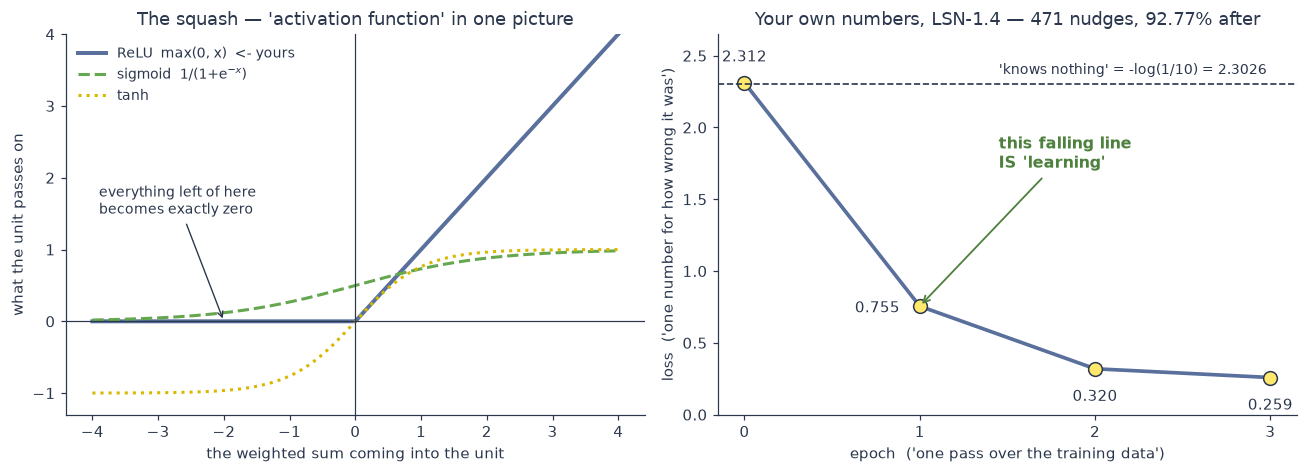

Use the right panel in a client conversation, not the left one. 'We showed it examples, it
was wrong, we nudged the dials, it got less wrong' - and the picture proves you watched it
happen. The left panel is for the one client in ten who asks why layers help at all.

Then the honest half, in the same breath - both numbers off your own lab:
  - 92.77% per digit means 723 of 10,000 digits wrong. On a five-digit invoice
    total, all five right is 0.9277^5 = 68.7%. Per-item accuracy is not per-document accuracy.
  - the SAME architecture on all 60,000 digits reached 97.04%. More labelled
    data, same model, no cleverness - which is the whole of LSN-1.6, one session from now.


In [5]:
# --- FIGURE 1: the two pictures behind every sentence in this segment.
#     Left  - the squashes themselves. Right - YOUR loss curve from LSN-1.4, relabelled in vocabulary.
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))

# ---- left: three squashes
_z = np.linspace(-4, 4, 400)
axes[0].plot(_z, np.maximum(_z, 0), color=VSP["navy"], linewidth=2.6, label="ReLU  max(0, x)  <- yours")
axes[0].plot(_z, 1 / (1 + np.exp(-_z)), color=VSP["green"], linewidth=2.0, linestyle="--",
             label="sigmoid  1/(1+e$^{-x}$)")
axes[0].plot(_z, np.tanh(_z), color=VSP["gold_dark"], linewidth=2.0, linestyle=":", label="tanh")
axes[0].axhline(0, color=VSP["ink"], linewidth=0.8)
axes[0].axvline(0, color=VSP["ink"], linewidth=0.8)
axes[0].annotate("everything left of here\nbecomes exactly zero", xy=(-2.0, 0), xytext=(-3.9, 1.5),
                 fontsize=9, color=VSP["ink"],
                 arrowprops=dict(arrowstyle="->", color=VSP["ink"], linewidth=0.9))
axes[0].set_xlabel("the weighted sum coming into the unit")
axes[0].set_ylabel("what the unit passes on")
axes[0].set_title("The squash — 'activation function' in one picture", fontsize=12)
axes[0].set_ylim(-1.3, 4.0)
axes[0].legend(fontsize=9, loc="upper left")
axes[0].spines[["top", "right"]].set_visible(False)

# ---- right: the real LSN-1.4 loss curve, annotated with the words
_xs = [0, 1, 2, 3]
_ys = [LAB["loss_first"], *LAB["loss_epochs"]]
axes[1].plot(_xs, _ys, "o-", color=VSP["navy"], linewidth=2.4, markersize=9,
             markerfacecolor=VSP["yellow"], markeredgecolor=VSP["ink"])
axes[1].axhline(np.log(10), color=VSP["ink"], linestyle="--", linewidth=1.1)
axes[1].text(2.98, np.log(10) + 0.07, "'knows nothing' = -log(1/10) = 2.3026", ha="right", fontsize=9,
             color=VSP["ink"])
# Label placement, checked by looking at the render (SI-19): epoch 0 above the point, epoch 1
# to its LEFT (the annotation arrow lands to its right), the last two below the curve.
_offsets = {0: ((0, 14), "center"), 1: ((-13, -4), "right"), 2: ((0, -21), "center"),
            3: ((0, -21), "center")}
for _x, _y in zip(_xs, _ys):
    _off, _ha = _offsets[_x]
    axes[1].annotate(f"{_y:.3f}", (_x, _y), textcoords="offset points", xytext=_off, ha=_ha,
                     fontsize=9.5, color=VSP["ink"])
axes[1].annotate("this falling line\nIS 'learning'", xy=(1, LAB["loss_epochs"][0]), xytext=(1.45, 1.72),
                 fontsize=10.5, fontweight="bold", color=VSP["green_dark"],
                 arrowprops=dict(arrowstyle="->", color=VSP["green_dark"], linewidth=1.2))
axes[1].set_xlabel("epoch  ('one pass over the training data')")
axes[1].set_ylabel("loss  ('one number for how wrong it was')")
axes[1].set_title(f"Your own numbers, LSN-1.4 — {LAB['steps']} nudges, {LAB['test_acc']:.2%} after",
                  fontsize=12)
axes[1].set_xticks(_xs)
axes[1].set_ylim(0, 2.65)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("Use the right panel in a client conversation, not the left one. 'We showed it examples, it")
print("was wrong, we nudged the dials, it got less wrong' - and the picture proves you watched it")
print("happen. The left panel is for the one client in ten who asks why layers help at all.")
print()
print("Then the honest half, in the same breath - both numbers off your own lab:")
print(f"  - {LAB['test_acc']:.2%} per digit means "
      f"{round((1 - LAB['test_acc']) * 10_000):,} of 10,000 digits wrong. On a five-digit invoice")
print(f"    total, all five right is {LAB['test_acc']:.4f}^5 = {COMPOUND_5:.1%}. "
      f"Per-item accuracy is not per-document accuracy.")
print(f"  - the SAME architecture on all 60,000 digits reached {LAB['full_acc']:.2%}. More labelled")
print("    data, same model, no cleverness - which is the whole of LSN-1.6, one session from now.")

assert abs(COMPOUND_5 - 0.687) < 0.001, COMPOUND_5          # pinned: LSN-1.4's compounding beat
assert round((1 - LAB["test_acc"]) * 10_000) == 723          # pinned: LSN-1.4's error count

## "Deep learning" — the same thing, with enough layers to invent its own columns

`LSN-1.1` gave you the nesting doll: **AI ⊃ machine learning ⊃ deep learning ⊃ generative AI.** So *deep
learning is a subset of machine learning* — the subset where the model is a neural network with several layers.
That is the whole definition, and it means the skeptical VP in drill prompt 3 is **half right**: the word is
absolutely used as marketing. It also names something real.

**What the layers actually buy you: you stop hand-engineering features.** That claim is testable in ten seconds,
and the next cell tests it on the hardest-to-fake shape there is — **two rings**, one inside the other. Three
models, one number each:

1. a **straight-line** model (logistic regression) on the raw two columns;
2. the *same* straight-line model, after **a human engineers one feature** — distance from the centre;
3. a **small neural network** (two hidden layers, 91 parameters) on the raw two columns.

Watch what the third one does without being told that "distance from the centre" is the idea. **That is what
"learns its own features" means**, and it is exactly what happened in your lab: nobody told your model what a
loop or a stroke is. It got 784 raw pixel values and worked the rest out.

In [6]:
# --- DOES DEPTH BUY ANYTHING? Two rings, three models. Expected runtime: about a second.
#     Every one of these is a PROP (LSN-1.2's word): 600 points of synthetic geometry is not
#     evidence about any client's problem. The CONTRAST between the three numbers is the point.
X_rings, y_rings = make_circles(n_samples=600, noise=0.12, factor=0.45, random_state=42)
Xtr, Xte, ytr, yte = train_test_split(X_rings, y_rings, test_size=0.25, random_state=42,
                                      stratify=y_rings)

# 1. a straight line, on the raw x/y columns
line = LogisticRegression().fit(Xtr, ytr)

# 2. the SAME straight-line model, after a human engineers the one feature that matters
R = np.sqrt((X_rings ** 2).sum(axis=1)).reshape(-1, 1)          # distance from the centre
Rtr, Rte, _, _ = train_test_split(R, y_rings, test_size=0.25, random_state=42, stratify=y_rings)
line_engineered = LogisticRegression().fit(Rtr, ytr)

# 3. a small neural network on the raw x/y columns: 2 -> 10 -> 5 -> 1, ReLU, 91 parameters
net = MLPClassifier(hidden_layer_sizes=(10, 5), activation="relu", solver="adam",
                    max_iter=4_000, random_state=42).fit(Xtr, ytr)
net_params = sum(c.size for c in net.coefs_) + sum(i.size for i in net.intercepts_)

_rows = pd.DataFrame({
    "model": ["straight line (raw x, y)", "straight line + human-engineered 'distance from centre'",
              "neural net, 2 hidden layers (raw x, y)"],
    "parameters": [3, 2, net_params],
    "features given": ["the 2 raw columns", "1 column a human computed", "the 2 raw columns"],
    "held-out accuracy": [f"{line.score(Xte, yte):.2%}", f"{line_engineered.score(Rte, yte):.2%}",
                          f"{net.score(Xte, yte):.2%}"],
})
show(_rows)

print()
print(f"straight line, raw columns             : {line.score(Xte, yte):.2%}   "
      f"<- worse than guessing. No straight line separates a ring from a ring.")
print(f"straight line + engineered feature     : {line_engineered.score(Rte, yte):.2%}   "
      f"<- a HUMAN had the idea; the model just used it")
print(f"neural net, {net_params} parameters, raw columns : {net.score(Xte, yte):.2%}   "
      f"<- nobody mentioned 'distance from the centre'")
print(f"                                        (trained in {net.n_iter_} iterations, final loss "
      f"{net.loss_:.4f})")
print()
print("THE SENTENCE THIS BUYS YOU, for the skeptical VP:")
print("  'Deep learning is machine learning where the model is a neural network with several")
print("   layers. What the layers buy you is that it works out its own features. Here: a linear")
print("   model on two raw columns gets it wrong more often than a coin. Hand it one feature a")
print("   human thought of and it is perfect. A 91-parameter network gets there on the raw")
print("   columns, because the middle layers built that feature themselves. Real - and not magic:")
print("   it needs more data than the simple model, and it is harder to explain when it is wrong.'")
print()
print("And the callback that makes it yours: nobody engineered features for your MNIST model")
print(f"either. It got 784 raw pixel brightnesses and {LAB['test_acc']:.2%} came out the other end.")

# --- pinned: these are the numbers the deck and the model answers quote (SI-17)
assert net_params == 91, net_params
assert abs(line.score(Xte, yte) - 0.4733) < 0.005, line.score(Xte, yte)
assert abs(line_engineered.score(Rte, yte) - 1.0) < 0.005
assert abs(net.score(Xte, yte) - 1.0) < 0.005
print("\n[PASS] Pinned: 47.33% straight line / 100% engineered feature / 100% net at 91 parameters.")

,model,parameters,features given,held-out accuracy
0,"straight line (raw x, y)",3,the 2 raw columns,47.33%
1,straight line + human-engineered 'distance fro...,2,1 column a human computed,100.00%
2,"neural net, 2 hidden layers (raw x, y)",91,the 2 raw columns,100.00%



straight line, raw columns             : 47.33%   <- worse than guessing. No straight line separates a ring from a ring.
straight line + engineered feature     : 100.00%   <- a HUMAN had the idea; the model just used it
neural net, 91 parameters, raw columns : 100.00%   <- nobody mentioned 'distance from the centre'
                                        (trained in 706 iterations, final loss 0.0598)

THE SENTENCE THIS BUYS YOU, for the skeptical VP:
  'Deep learning is machine learning where the model is a neural network with several
   layers. What the layers buy you is that it works out its own features. Here: a linear
   model on two raw columns gets it wrong more often than a coin. Hand it one feature a
   human thought of and it is perfect. A 91-parameter network gets there on the raw
   columns, because the middle layers built that feature themselves. Real - and not magic:
   it needs more data than the simple model, and it is harder to explain when it is wrong.'

And the call

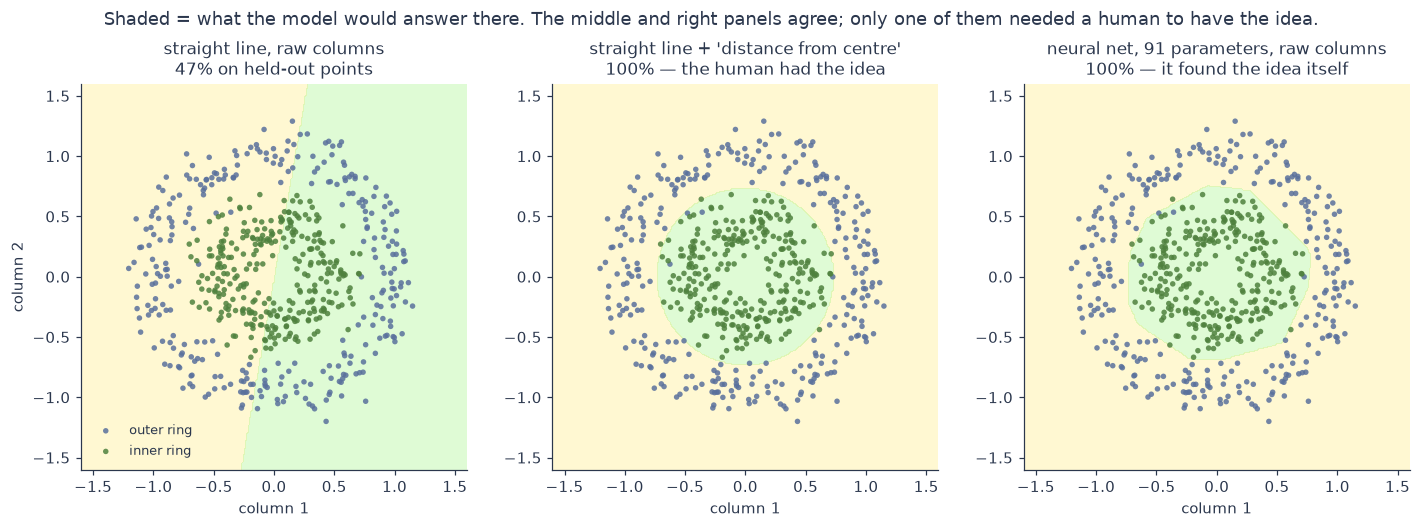

Say the middle and right panels together, in this order, and the VP's question answers itself:
  'A human can always engineer the feature - if a human knows what the feature is. On your
   site photos, nobody can write down the feature. That is when the layers earn their fee.'


In [7]:
# --- FIGURE 2: the same three models, drawn. A picture beats the table when a client is in the room.
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.5))
_xx, _yy = np.meshgrid(np.linspace(-1.6, 1.6, 300), np.linspace(-1.6, 1.6, 300))
_grid = np.c_[_xx.ravel(), _yy.ravel()]
_grid_r = np.sqrt((_grid ** 2).sum(axis=1)).reshape(-1, 1)
_cmap = plt.matplotlib.colors.ListedColormap([VSP["yellow"], VSP["mint"]])

for _ax, (_title, _pred) in zip(axes, (
        (f"straight line, raw columns\n{line.score(Xte, yte):.0%} on held-out points",
         line.predict(_grid)),
        (f"straight line + 'distance from centre'\n{line_engineered.score(Rte, yte):.0%} — the human had the idea",
         line_engineered.predict(_grid_r)),
        (f"neural net, {net_params} parameters, raw columns\n{net.score(Xte, yte):.0%} — it found the idea itself",
         net.predict(_grid)))):
    _ax.contourf(_xx, _yy, _pred.reshape(_xx.shape), alpha=0.30, cmap=_cmap, levels=1)
    for _cls, _colour, _label in ((0, VSP["navy"], "outer ring"), (1, VSP["green_dark"], "inner ring")):
        _m = y_rings == _cls
        _ax.scatter(X_rings[_m, 0], X_rings[_m, 1], s=13, color=_colour, edgecolor="none",
                    alpha=0.85, label=_label)
    _ax.set_title(_title, fontsize=11)
    _ax.set_xlim(-1.6, 1.6)
    _ax.set_ylim(-1.6, 1.6)
    _ax.set_aspect("equal")
    _ax.set_xlabel("column 1")
    _ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("column 2")
axes[0].legend(fontsize=8.5, loc="lower left")

fig.suptitle("Shaded = what the model would answer there. The middle and right panels agree; only one "
             "of them needed a human to have the idea.", fontsize=11.5, y=1.005)
plt.tight_layout()
plt.show()

print("Say the middle and right panels together, in this order, and the VP's question answers itself:")
print("  'A human can always engineer the feature - if a human knows what the feature is. On your")
print("   site photos, nobody can write down the feature. That is when the layers earn their fee.'")

---

# Segment 2 — CNNs: why images want convolutions *(15 min)*

## A photo is not a spreadsheet, and your lab model didn't know that

Your MNIST model got the image as **784 numbers in a row**. That worked — 92.77% — and it worked *despite* a
genuinely silly handicap, which `LSN-1.4` said out loud: the model **never learned that pixel 100 sits directly
above pixel 128.** The 2-D layout was thrown away at the door. Two consequences, and they are the two words you
need:

- **Locality.** Meaning in an image is local: an edge, a corner, a texture live in a small patch of neighbouring
  pixels. A flat row of 784 numbers has no notion of "neighbouring".
- **Reuse.** A vertical edge in the top-left corner and a vertical edge in the bottom-right corner are *the same
  pattern*. A plain network has to learn each position separately — every one of `Linear(784, 128)`'s **100,352
  weights** is tied to one specific pixel.

A **convolutional** network fixes both with one idea: **learn a small pattern detector, and slide it across the
whole picture.** Nine weights, used everywhere. That is the entire concept, and the next two cells do it to a
real digit — the *same* test image 0 you pushed through your own network by hand last session.

**No math, one picture, as the lesson plan asks.** The picture is the feature map: for every position in the
image, "how strongly did my detector fire here?"

In [8]:
# --- The digit. Read from the SAME pre-warmed MNIST cache your lab used (SI-24b) - this is
#     literally test image 0, the one you hand-computed a forward pass for in LSN-1.4.
try:
    _mnist_test = datasets.MNIST(root=DATA_ROOT, train=False, download=False)
    _img, DIGIT_LABEL = _mnist_test[0]
    digit = np.asarray(_img, dtype=np.float64) / 255.0
    DATA_IS_REAL = True
except Exception as _exc:                       # offline fallback (SI-27d): a hand-drawn 7
    DATA_IS_REAL, DIGIT_LABEL = False, 7
    digit = np.zeros((28, 28))
    digit[6, 7:21] = 1.0                        # the top stroke
    for _r, _c in zip(range(7, 23), np.linspace(19, 11, 16)):
        digit[_r, int(round(_c))] = 1.0         # the diagonal
    print(f"[WARN] MNIST cache not readable ({type(_exc).__name__}). Using a synthetic 7 so the")
    print("       notebook still runs end to end - the shapes are right, the numbers will differ,")
    print("       and every MNIST-pinned assert below is skipped. See LSN-1.4's pre-work gate.")

# --- Two 3x3 pattern detectors. Nine numbers each. NOT learned - hand-written, so you can see
#     that there is nothing else in a convolution than this.
K_VERT = np.array([[1.0, 0.0, -1.0],       # bright on the left, dark on the right -> fires positive
                   [2.0, 0.0, -2.0],
                   [1.0, 0.0, -1.0]])
K_HORZ = np.array([[ 1.0,  2.0,  1.0],     # bright above, dark below
                   [ 0.0,  0.0,  0.0],
                   [-1.0, -2.0, -1.0]])


def convolve(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """Slide `kernel` over `image` and record the response at every position. The whole operation."""
    kh, kw = kernel.shape
    out = np.zeros((image.shape[0] - kh + 1, image.shape[1] - kw + 1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = float((image[i:i + kh, j:j + kw] * kernel).sum())   # <- 9 multiplies, 1 add
    return out


vert = convolve(digit, K_VERT)
horz = convolve(digit, K_HORZ)
magnitude = np.sqrt(vert ** 2 + horz ** 2)

print(f"the image  : {digit.shape}  ({int((digit > 0).sum())} of its {digit.size} pixels are ink; "
      f"a human labelled it {DIGIT_LABEL})")
print(f"the filter : {K_VERT.shape}  -> 9 weights + 1 bias = 10 numbers")
print(f"the output : {vert.shape}  <- one response per position the filter fit. "
      f"That grid IS the 'feature map'.")
print()

# ---- ONE WINDOW, spelled out. The strongest horizontal-edge response in the whole image.
# NB: named in CAPS on purpose - the figure cell below reads them, and IPython rebinds
# any variable called _i to the previous cell's source text between cells.
WIN_R, WIN_C = np.unravel_index(np.argmax(np.abs(horz)), horz.shape)
_patch = digit[WIN_R:WIN_R + 3, WIN_C:WIN_C + 3]
print(f"THE ARITHMETIC OF ONE WINDOW - the filter's strongest hit, at row {WIN_R}, column {WIN_C}:")
print("   the 3x3 patch of the image        the filter            product")
for _r in range(3):
    _prod = _patch[_r] * K_HORZ[_r]
    print(f"     {str(np.round(_patch[_r], 3).tolist()):<28} {str(K_HORZ[_r].tolist()):<22} "
          f"{np.round(_prod, 3).tolist()}")
print(f"   sum of the nine products = {horz[WIN_R, WIN_C]:+.4f}    <- ONE number of the feature map")
print()
print("   Read it: the top row of the patch is blank paper (zeros) and the bottom row is solid ink")
print(f"   at brightness {_patch[2, 0]:.3f}. So the sum is -({_patch[2, 0]:.3f} x (1+2+1)) = "
      f"{horz[WIN_R, WIN_C]:+.4f} - a strong, negative,")
print("   'dark-above-bright' response. That is what 'it detects an edge' means, arithmetically.")
print()
print(f"vertical-edge map   : responses run {vert.min():+.3f} to {vert.max():+.3f}")
print(f"horizontal-edge map : responses run {horz.min():+.3f} to {horz.max():+.3f}")

if DATA_IS_REAL:
    assert DIGIT_LABEL == 7, DIGIT_LABEL
    assert int((digit > 0).sum()) == 116
    assert (WIN_R, WIN_C) == (6, 7), (WIN_R, WIN_C)
    assert abs(horz[WIN_R, WIN_C] - (-3.9843)) < 1e-4, horz[WIN_R, WIN_C]
    assert abs(vert.max() - 3.9804) < 1e-4, vert.max()
    print("\n[PASS] Pinned to MNIST test image 0 (a 7, 116 ink pixels): strongest horizontal window")
    print("       at row 6 col 7 = -3.9843; strongest vertical response 3.9804.")
else:
    print("\n[SKIP] MNIST-pinned asserts skipped - running on the synthetic digit (DATA_IS_REAL=False).")

the image  : (28, 28)  (116 of its 784 pixels are ink; a human labelled it 7)
the filter : (3, 3)  -> 9 weights + 1 bias = 10 numbers
the output : (26, 26)  <- one response per position the filter fit. That grid IS the 'feature map'.

THE ARITHMETIC OF ONE WINDOW - the filter's strongest hit, at row 6, column 7:
   the 3x3 patch of the image        the filter            product
     [0.0, 0.0, 0.0]              [1.0, 2.0, 1.0]        [0.0, 0.0, 0.0]
     [0.725, 0.624, 0.592]        [0.0, 0.0, 0.0]        [0.0, 0.0, 0.0]
     [0.996, 0.996, 0.996]        [-1.0, -2.0, -1.0]     [-0.996, -1.992, -0.996]
   sum of the nine products = -3.9843    <- ONE number of the feature map

   Read it: the top row of the patch is blank paper (zeros) and the bottom row is solid ink
   at brightness 0.996. So the sum is -(0.996 x (1+2+1)) = -3.9843 - a strong, negative,
   'dark-above-bright' response. That is what 'it detects an edge' means, arithmetically.

vertical-edge map   : responses run -3.937 t

In [9]:
# --- REUSE, proved. Shift the digit four pixels right and run the SAME filter again. Nothing is
#     retrained, nothing is re-tuned: the detector simply fires four pixels further along.
shifted = np.zeros_like(digit)
shifted[:, 4:] = digit[:, :-4]
vert_shifted = convolve(shifted, K_VERT)
horz_shifted = convolve(shifted, K_HORZ)

_iv, _jv = np.unravel_index(np.argmax(np.abs(vert)), vert.shape)
_iv2, _jv2 = np.unravel_index(np.argmax(np.abs(vert_shifted)), vert_shifted.shape)

print("THE REUSE ARGUMENT, MEASURED:")
print(f"  original : strongest vertical-edge response at row {_iv}, col {_jv}  = {vert[_iv, _jv]:+.4f}")
print(f"  shifted  : strongest vertical-edge response at row {_iv2}, col {_jv2}  "
      f"= {vert_shifted[_iv2, _jv2]:+.4f}")
print(f"  the digit moved 4 columns; the response moved {_jv2 - _jv} columns; the VALUE is "
      f"{'identical' if abs(vert[_iv, _jv] - vert_shifted[_iv2, _jv2]) < 1e-12 else 'different'}.")
print(f"  in fact the whole map just slid: max |shifted_map[:, 4:] - map[:, :-4]| = "
      f"{np.abs(vert_shifted[:, 4:] - vert[:, :-4]).max():.2e}")
print()
print("Now compare that with the plain network you actually trained. Its first layer holds one")
print(f"weight per pixel per unit - {784 * 128:,} of them - so 'a vertical edge' had to be learned")
print("separately for every position it could appear in. Move the digit four pixels and, as far as")
print("that layer is concerned, it is a different input entirely.")
print()
print("THE CLIENT-SAFE VERSION, for the ops director:")
print("  'The normal network sees your photo as a flat list of pixel values and has to learn what a")
print("   scaffold looks like separately for every spot in the frame. The convolutional one learns")
print("   one small scaffold-detector - nine numbers - and slides it over the whole photo. Same")
print("   detector, anywhere in the frame, no retraining. That is why vision uses these.'")

assert np.allclose(vert_shifted[:, 4:], vert[:, :-4], atol=1e-12), "a shifted image must shift the map"
assert _jv2 - _jv == 4, (_jv, _jv2)
print(f"\n[PASS] Translation reuse verified exactly: the feature map shifted by 4 columns, unchanged.")

THE REUSE ARGUMENT, MEASURED:
  original : strongest vertical-edge response at row 22, col 13  = +3.9804
  shifted  : strongest vertical-edge response at row 22, col 17  = +3.9804
  the digit moved 4 columns; the response moved 4 columns; the VALUE is identical.
  in fact the whole map just slid: max |shifted_map[:, 4:] - map[:, :-4]| = 0.00e+00

Now compare that with the plain network you actually trained. Its first layer holds one
weight per pixel per unit - 100,352 of them - so 'a vertical edge' had to be learned
separately for every position it could appear in. Move the digit four pixels and, as far as
that layer is concerned, it is a different input entirely.

THE CLIENT-SAFE VERSION, for the ops director:
  'The normal network sees your photo as a flat list of pixel values and has to learn what a
   scaffold looks like separately for every spot in the frame. The convolutional one learns
   one small scaffold-detector - nine numbers - and slides it over the whole photo. Same
   de

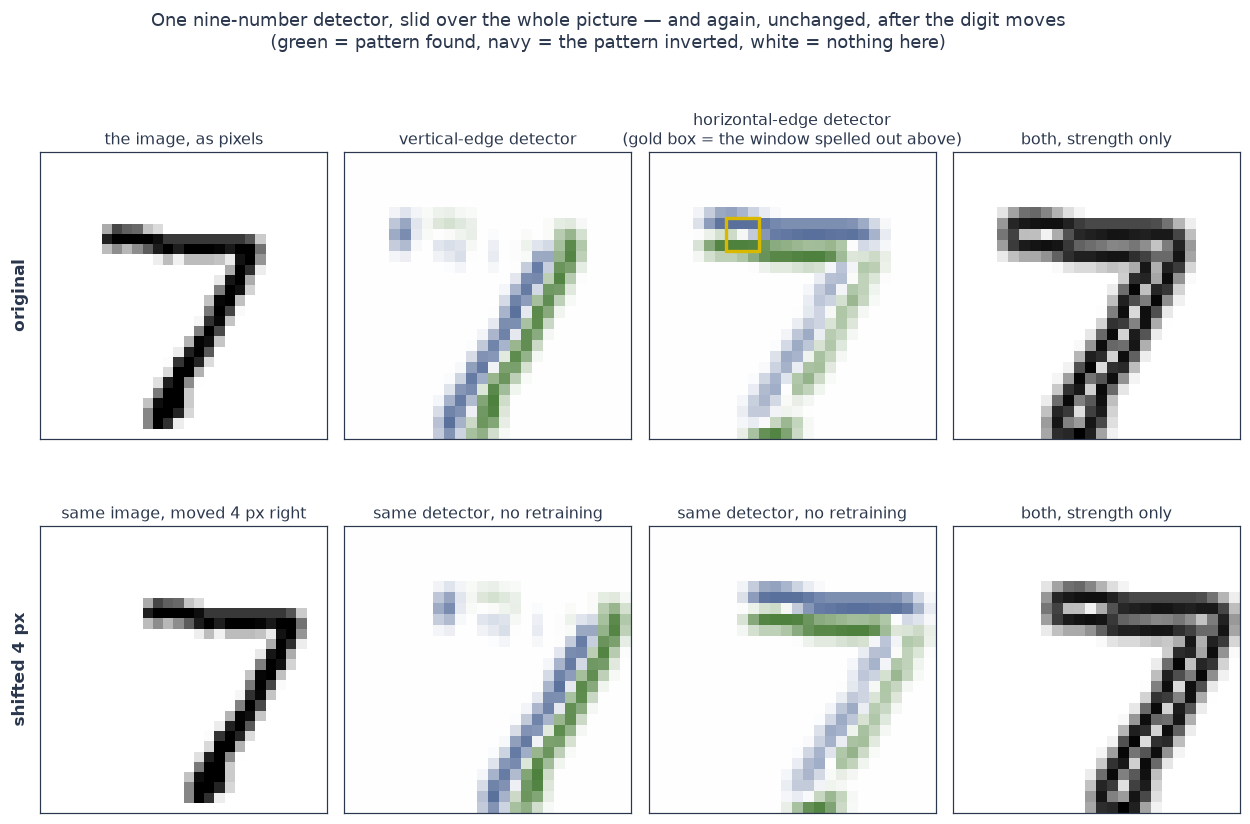

Two things to say out loud about this figure, and then stop talking:
  1. Nobody trained these filters. They are nine hand-written numbers, and they already find
     the strokes. A real CNN LEARNS the nine numbers - and dozens of sets of them per layer.
  2. The bottom row is the entire commercial argument. Same detector, moved subject, same
     answer. A flat pixel-row network has to learn that lesson once per position.


In [10]:
# --- FIGURE 3: the whole segment in one picture. Top row: the digit and what two nine-number
#     detectors see in it. Bottom row: the SAME detectors on the shifted digit.
_edge_cmap = plt.matplotlib.colors.LinearSegmentedColormap.from_list(
    "vsp_edge", [VSP["navy"], "#ffffff", VSP["green_dark"]])      # negative -> navy, positive -> green
_lim = max(np.abs(vert).max(), np.abs(horz).max())

fig, axes = plt.subplots(2, 4, figsize=(11.6, 7.6))
_panels = [
    ("the image, as pixels", digit, "gray_r", (0, 1)),
    ("vertical-edge detector", vert, _edge_cmap, (-_lim, _lim)),
    ("horizontal-edge detector\n(gold box = the window spelled out above)", horz,
     _edge_cmap, (-_lim, _lim)),
    ("both, strength only", magnitude, "gray_r", (0, magnitude.max())),
    ("same image, moved 4 px right", shifted, "gray_r", (0, 1)),
    ("same detector, no retraining", vert_shifted, _edge_cmap, (-_lim, _lim)),
    ("same detector, no retraining", horz_shifted, _edge_cmap, (-_lim, _lim)),
    ("both, strength only", np.sqrt(vert_shifted ** 2 + horz_shifted ** 2), "gray_r",
     (0, magnitude.max())),
]
for _ax, (_title, _data, _cm, (_vmin, _vmax)) in zip(axes.ravel(), _panels):
    _ax.imshow(_data, cmap=_cm, vmin=_vmin, vmax=_vmax)
    _ax.set_title(_title, fontsize=10.5, color=VSP["ink"], pad=5)
    _ax.set_xticks([])
    _ax.set_yticks([])
for _ax, _row in zip(axes[:, 0], ("original", "shifted 4 px")):
    _ax.set_ylabel(_row, fontsize=11, fontweight="bold", color=VSP["ink"], labelpad=8)
# mark the window whose arithmetic was printed above (its caption is in that panel's title -
# inside the panel it landed on top of the response band).
axes[0, 2].add_patch(plt.Rectangle((WIN_C - 0.5, WIN_R - 0.5), 3, 3, fill=False,
                                   edgecolor=VSP["gold_dark"], linewidth=2.2))

fig.suptitle("One nine-number detector, slid over the whole picture — and again, unchanged, after the "
             "digit moves\n(green = pattern found, navy = the pattern inverted, white = nothing here)",
             fontsize=12, y=1.00)
# Explicit margins: imshow pins each panel square, so tight_layout cannot add the room the
# second row of titles needs - at 7.4in the row-2 titles landed on row 1 (SI-19).
fig.subplots_adjust(left=0.055, right=0.995, top=0.855, bottom=0.015, hspace=0.14,
                    wspace=0.06)
plt.show()

print("Two things to say out loud about this figure, and then stop talking:")
print("  1. Nobody trained these filters. They are nine hand-written numbers, and they already find")
print("     the strokes. A real CNN LEARNS the nine numbers - and dozens of sets of them per layer.")
print("  2. The bottom row is the entire commercial argument. Same detector, moved subject, same")
print("     answer. A flat pixel-row network has to learn that lesson once per position.")

In [11]:
# --- The parameter arithmetic, because "cheaper" is a claim and claims get checked.
#     Every number here is counted, not quoted.
_img_positions = 28 * 28          # a padded 3x3 convolution produces one output per input pixel
_rows = pd.DataFrame([
    {"layer": "your lab model: Linear(784, 128)", "parameters": 784 * 128 + 128,
     "what it is": "one weight per pixel per unit - position by position"},
    {"layer": "ONE 3x3 convolutional filter", "parameters": 3 * 3 + 1,
     "what it is": f"nine weights + a bias, reused at all {_img_positions} positions"},
    {"layer": "32 filters of 3x3 (source notebook 02's conv1)", "parameters": 32 * (3 * 3) + 32,
     "what it is": "32 different detectors, each slid over the whole image"},
    {"layer": "+ 64 filters of 3x3 over those (conv2)", "parameters": 64 * (32 * 3 * 3) + 64,
     "what it is": "detectors OF detectors - this is where 'edges into shapes' happens"},
    {"layer": "its dense head: Linear(64*7*7, 128)", "parameters": 64 * 7 * 7 * 128 + 128,
     "what it is": "the expensive part of a small CNN is NOT the convolutions"},
])
show(_rows)

print()
print(f"One filter is {100_480 / 10:,.0f}x smaller than your lab model's first layer, and it works "
      f"everywhere in the frame.")
print(f"Ten numbers, used {_img_positions} times per image. That trade - fewer weights, applied more "
      f"often - is\nthe whole of 'reuse and locality', and it is why the construction-site prospect "
      f"needs this\narchitecture rather than the one you built last session.")
print()
print("The honest half, and say it before the client asks:")
print(f"  · a CNN still needs LABELLED images, and a lot of them. Your own curve priced it: "
      f"{LAB['acc_200']:.2%}")
print(f"    on {200} clean, centred, single-object examples - and site photos are not clean, centred")
print(f"    or single-object. Trained to equal compute the same 200 reached "
      f"{LAB['acc_200_equal']:.2%}, which is")
print(f"    the honest ceiling for 'we have about 200 photos'.")
print("  · it is sensitive to framing: camera angle, lighting and distance all change the pixels.")
print("    'Mount the camera in the same place every time' is a real deliverable, not a detail.")
print("  · the usual real answer is a PRE-TRAINED vision model fine-tuned on their photos, not a")
print("    network trained from scratch. Same vocabulary, a tenth of the labelling bill.")

assert int(_rows.loc[0, "parameters"]) == 100_480
assert int(_rows.loc[1, "parameters"]) == 10
assert int(_rows.loc[2, "parameters"]) == 320
assert int(_rows.loc[3, "parameters"]) == 18_496
assert int(_rows.loc[4, "parameters"]) == 401_536
print("\n[PASS] Parameter counts exact: 100,480 · 10 · 320 · 18,496 · 401,536.")

,layer,parameters,what it is
0,"your lab model: Linear(784, 128)",100480,one weight per pixel per unit - position by po...
1,ONE 3x3 convolutional filter,10,"nine weights + a bias, reused at all 784 posit..."
2,32 filters of 3x3 (source notebook 02's conv1),320,"32 different detectors, each slid over the who..."
3,+ 64 filters of 3x3 over those (conv2),18496,detectors OF detectors - this is where 'edges ...
4,"its dense head: Linear(64*7*7, 128)",401536,the expensive part of a small CNN is NOT the c...



One filter is 10,048x smaller than your lab model's first layer, and it works everywhere in the frame.
Ten numbers, used 784 times per image. That trade - fewer weights, applied more often - is
the whole of 'reuse and locality', and it is why the construction-site prospect needs this
architecture rather than the one you built last session.

The honest half, and say it before the client asks:
  · a CNN still needs LABELLED images, and a lot of them. Your own curve priced it: 64.41%
    on 200 clean, centred, single-object examples - and site photos are not clean, centred
    or single-object. Trained to equal compute the same 200 reached 82.90%, which is
    the honest ceiling for 'we have about 200 photos'.
  · it is sensitive to framing: camera angle, lighting and distance all change the pixels.
    'Mount the camera in the same place every time' is a real deliverable, not a detail.
  · the usual real answer is a PRE-TRAINED vision model fine-tuned on their photos, not a
    network 

### Stacking — how "edges" become "is the slab poured?"

One layer of filters on raw pixels finds **edges and blobs**. Feed those maps into a *second* layer of filters
and it finds **combinations of edges** — corners, junctions, textures. A third finds **parts**; a fourth finds
**objects**. Pooling (taking the maximum of each little 2×2 block) shrinks the maps between layers, so a filter
late in the stack is looking at a small window of a much-shrunk map — which means it is effectively looking at a
*large* region of the original photo. That is the entire architecture, and it is why the reference notebook's
`SimpleCNN` goes `28×28 → 14×14 → 7×7` on its way to ten scores.

**The client-safe version, for the construction prospect's ops director:**

> *"Your photos aren't spreadsheets — what a thing is depends on the pixels next to it. So instead of one
> weight per pixel, we learn small pattern detectors and slide them over the whole photo: the first layer finds
> edges, the next finds corners and textures, the next finds shapes, and the top of the stack finds 'that's a
> poured slab'. Same detector works anywhere in the frame, which is why this is the architecture for vision.
> What it needs from you is labelled photos — a lot of them — and cameras that don't move. How many photos do
> you have, and does anyone mark up what's in them today?"*

That last sentence is `LSN-1.6`'s whole lesson arriving early, and it is the honest-boundary row of the rubric.

---

# Segment 3 — RL: learning by reward *(15 min)*

## The third learning signal

Everything you have seen in `MOD-1` so far learns from one of two signals. Reinforcement learning is the third,
and knowing which of the three a client's problem has is a triage skill worth more than the vocabulary.

| Signal | What the data looks like | What you get | Where you met it |
|---|---|---|---|
| **Labels** (supervised) | rows with the right answer attached — 60,000 digits, each tagged `7` | a model that maps input → answer | `LSN-1.4`, your MNIST run; `LSN-1.1`'s classify / regress / propensity |
| **No labels** (unsupervised) | rows with no answer column at all | groups, associations, structure a human then names | `LSN-1.1`/`LSN-1.2`'s cluster job |
| **Reward** (reinforcement) | no dataset — an **environment** it can act in, and a number that says how well that went | a **policy**: what to do in each situation | this segment; and RLHF, which shaped the models in `MOD-2` |

**The loop, in five nouns.** An **agent** observes a **state**, picks an **action**, receives a **reward**, lands
in a new state, and updates its **policy**. No teacher ever says *"the correct move was right"* — only *"that
went well"* or *"that went badly"*, usually much later than the move that caused it.

**Q-learning**, the algorithm in the reference notebook and in the cell below, is the simplest honest version:
keep a table of *"how good is action `a` in state `s`?"*, act mostly on the best-known action but sometimes at
random (**exploration vs exploitation** — you cannot discover a better route without occasionally leaving the
one you know), and after every single step nudge one entry of that table toward what actually happened.

The next cell is a **5×5 grid**: start top-left, goal bottom-right, four moves, `-1` for every step, `+10` for
reaching the goal. Twenty-five squares — about the simplest routing problem that exists — and the honest answer
to the warehouse client lives in **how much trial and error it takes**.

In [12]:
# --- Q-LEARNING ON A 5x5 GRID. A port of notebooks/reinforcement/01_Reinforcement_QLearning.ipynb's
#     grid world and agent, with two changes: every random draw is seeded (SI-3 - the original is
#     not, so its numbers differ on every run), and we run it three times with three different
#     REWARD designs. Expected runtime: about a second for all three.
GRID = 5
GOAL = (GRID - 1, GRID - 1)
BONUS_CELL = (2, 2)                       # a "high-value shelf" in the middle of the floor
MOVES = [(-1, 0), (0, 1), (1, 0), (0, -1)]
MOVE_NAMES = ["up", "right", "down", "left"]
ARROWS = ["↑", "→", "↓", "←"]


def q_learn(bonus=0.0, bonus_once=False, episodes=500, seed=SEED, alpha=0.1, gamma=0.9,
            eps=1.0, eps_decay=0.995, eps_min=0.01, step_reward=-1.0, cap=100):
    """Train a tabular Q-learning agent on the grid. Returns the Q-table and per-episode history."""
    rng = np.random.default_rng(seed)                 # seeded: identical numbers on every run
    Q = np.zeros((GRID, GRID, 4))                     # "how good is each move in each square?"
    steps_hist, reward_hist, reached, eps_hist, env_steps = [], [], [], [], 0

    for _ep in range(episodes):
        r, c, done, steps, total, took_bonus = 0, 0, False, 0, 0.0, False
        while not done and steps < cap:
            # ---- act: mostly the best known move, sometimes a random one (epsilon-greedy)
            action = int(rng.integers(4)) if rng.random() < eps else int(np.argmax(Q[r, c]))
            dr, dc = MOVES[action]
            nr = min(max(r + dr, 0), GRID - 1)        # walls: you bump and stay put
            nc = min(max(c + dc, 0), GRID - 1)
            # ---- the reward function. THIS is the object the client has to be able to write down.
            if (nr, nc) == GOAL:
                reward, done = 10.0, True
            elif bonus and (nr, nc) == BONUS_CELL and not (bonus_once and took_bonus):
                reward, took_bonus = bonus, True
            else:
                reward = step_reward
            # ---- learn: nudge this one entry toward reward + discounted best-next-value
            target = reward + (0.0 if done else gamma * Q[nr, nc].max())
            Q[r, c, action] += alpha * (target - Q[r, c, action])
            r, c, steps, total, env_steps = nr, nc, steps + 1, total + reward, env_steps + 1
        steps_hist.append(steps)
        reward_hist.append(total)
        reached.append(done)
        eps_hist.append(eps)
        eps = max(eps_min, eps * eps_decay)           # explore less as you learn more

    return dict(Q=Q, steps=np.array(steps_hist), rewards=np.array(reward_hist),
                reached=np.array(reached), eps=np.array(eps_hist), env_steps=env_steps)


def greedy_path(Q, cap=40):
    """Follow the learned policy from the start with no exploration. Returns (path, outcome)."""
    r, c, path, seen = 0, 0, [(0, 0)], set()
    for _ in range(cap):
        action = int(np.argmax(Q[r, c]))
        if ((r, c), action) in seen:
            return path, "loops forever"
        seen.add(((r, c), action))
        dr, dc = MOVES[action]
        nr, nc = min(max(r + dr, 0), GRID - 1), min(max(c + dc, 0), GRID - 1)
        if (nr, nc) == (r, c):
            return path, "walks into a wall"
        r, c = nr, nc
        path.append((r, c))
        if (r, c) == GOAL:
            return path, "reaches the goal"
    return path, "never finishes"


honest = q_learn()                                    # -1 per step, +10 at the goal
print("RUN A - the honest reward: -1 for every step, +10 for reaching the goal")
print(f"  episodes                                : 500")
print(f"  environment steps of trial and error    : {honest['env_steps']:,}")
print(f"  average steps, first 50 episodes         : {honest['steps'][:50].mean():.1f}   "
      f"<- flailing; epsilon is near 1.0, so it is mostly moving at random")
print(f"  average steps, last 50 episodes          : {honest['steps'][-50:].mean():.2f}   "
      f"<- 8 is optimal (4 right + 4 down)")
print(f"  episodes that reached the goal, last 50  : {honest['reached'][-50:].mean():.0%}")
HONEST_PATH, _outcome = greedy_path(honest["Q"])
print(f"  the learned policy, followed greedily    : {len(HONEST_PATH) - 1} steps, {_outcome}")
print(f"     {' -> '.join(str(s) for s in HONEST_PATH)}")
print()
print("THE NUMBER THAT MATTERS IN A PRE-SALES CONVERSATION:")
print(f"  {honest['env_steps']:,} trial moves to learn a 25-square grid with four possible moves.")
print("  100 state-action pairs. No obstacles, no noise, nothing moving, full knowledge of where")
print("  it is. That is the cheapest routing problem that can exist, and it needed eight thousand")
print("  attempts - because nobody ever told it a correct move; it had to bump into consequences.")
print()
print("  So the first question to the warehouse client is not about algorithms. It is:")
print("  'Where are the robots allowed to fail eight thousand times?'")

assert honest["env_steps"] == 8_152, honest["env_steps"]
assert abs(honest["steps"][-50:].mean() - 8.86) < 0.01, honest["steps"][-50:].mean()
assert honest["reached"][-50:].mean() == 1.0
assert len(HONEST_PATH) - 1 == 8 and _outcome == "reaches the goal"
print(f"\n[PASS] Pinned: 8,152 environment steps, last-50 average 8.86, greedy policy optimal at 8 steps.")

RUN A - the honest reward: -1 for every step, +10 for reaching the goal
  episodes                                : 500
  environment steps of trial and error    : 8,152
  average steps, first 50 episodes         : 47.8   <- flailing; epsilon is near 1.0, so it is mostly moving at random
  average steps, last 50 episodes          : 8.86   <- 8 is optimal (4 right + 4 down)
  episodes that reached the goal, last 50  : 100%
  the learned policy, followed greedily    : 8 steps, reaches the goal
     (0, 0) -> (0, 1) -> (0, 2) -> (1, 2) -> (1, 3) -> (1, 4) -> (2, 4) -> (3, 4) -> (4, 4)

THE NUMBER THAT MATTERS IN A PRE-SALES CONVERSATION:
  8,152 trial moves to learn a 25-square grid with four possible moves.
  100 state-action pairs. No obstacles, no noise, nothing moving, full knowledge of where
  it is. That is the cheapest routing problem that can exist, and it needed eight thousand
  attempts - because nobody ever told it a correct move; it had to bump into consequences.

  So the fir

In [13]:
# --- THE REWARD YOU WRITE DOWN IS THE REWARD YOU GET. Same agent, same grid, same seed.
#     One change: visiting the middle square (2, 2) - call it a high-value pick face - pays +3.
#     Nobody changed the goal. Watch what it optimises.
hacked = q_learn(bonus=3.0)                       # +3 EVERY time it enters (2, 2)
fixed = q_learn(bonus=3.0, bonus_once=True)       # +3 the FIRST time only, per episode

_table = pd.DataFrame([
    {"reward design": "A  -1 per step, +10 goal",
     "env steps used": f"{honest['env_steps']:,}",
     "avg steps (last 50)": f"{honest['steps'][-50:].mean():.2f}",
     "finished the job (last 50)": f"{honest['reached'][-50:].mean():.0%}",
     "learned policy": f"{greedy_path(honest['Q'])[1]}"},
    {"reward design": "B  ... plus +3 every visit to (2,2)",
     "env steps used": f"{hacked['env_steps']:,}",
     "avg steps (last 50)": f"{hacked['steps'][-50:].mean():.2f}",
     "finished the job (last 50)": f"{hacked['reached'][-50:].mean():.0%}",
     "learned policy": f"{greedy_path(hacked['Q'])[1]}"},
    {"reward design": "C  ... +3 for the FIRST visit only",
     "env steps used": f"{fixed['env_steps']:,}",
     "avg steps (last 50)": f"{fixed['steps'][-50:].mean():.2f}",
     "finished the job (last 50)": f"{fixed['reached'][-50:].mean():.0%}",
     "learned policy": f"{greedy_path(fixed['Q'])[1]}"},
])
show(_table)

HACKED_PATH, _hacked_outcome = greedy_path(hacked["Q"])
FIXED_PATH, _fixed_outcome = greedy_path(fixed["Q"])
print()
print(f"Run B's learned policy, followed greedily: {' -> '.join(str(s) for s in HACKED_PATH)}  "
      f"... and {_hacked_outcome}.")
print(f"  It found the +3 square and learned to bounce in and out of it. Forever. The goal is still")
print(f"  worth +10 and it does not care: an endless +3 every other move beats +10 once.")
print(f"  {hacked['reached'][-50:].mean():.0%} of its last 50 episodes delivered anything at all, and it "
      f"burned {hacked['env_steps']:,} steps")
print(f"  ({hacked['env_steps'] / honest['env_steps']:.1f}x run A) learning to do it.")
print()
print(f"Run C - the same bonus, collectable once per episode: {_fixed_outcome} in "
      f"{len(FIXED_PATH) - 1} steps,")
print(f"  and look at the route: {' -> '.join(str(s) for s in FIXED_PATH)}")
print(f"  It collects the bonus ON THE WAY. {'(2, 2) is on the path.' if BONUS_CELL in FIXED_PATH else ''}")
print("  Reward the thing you actually want, make it un-farmable, and the agent's cleverness is")
print("  suddenly on your side. That is the fix, and it is a design job, not a modelling job.")
print()
print("THE CLIENT-SAFE VERSION, for the warehouse-automation prospect:")
print("  'Maybe - and there are two questions I would put to your vendor first. One: where do the")
print("   robots get to fail thousands of times? A trivial 25-square grid took eight thousand")
print("   attempts, so this needs a simulator faithful enough that what it learns there transfers")
print("   to your floor. Two: what exactly is the reward, in numbers? I gave this agent a bonus for")
print("   visiting a high-value shelf and it learned to bounce in and out of that shelf and stopped")
print("   delivering - it optimised precisely what I wrote down instead of what I meant. Who checks")
print("   that maximising your reward is the same thing as running your warehouse well?'")

assert hacked["env_steps"] == 35_534, hacked["env_steps"]
assert abs(hacked["steps"][-50:].mean() - 97.40) < 0.01, hacked["steps"][-50:].mean()
assert abs(hacked["reached"][-50:].mean() - 0.06) < 1e-9, hacked["reached"][-50:].mean()
assert _hacked_outcome == "loops forever"
assert fixed["env_steps"] == 8_298 and len(FIXED_PATH) - 1 == 8
assert BONUS_CELL in FIXED_PATH, "the once-only bonus should be collected en route"
print("\n[PASS] Pinned: reward-farming run loops forever (6% of last-50 episodes finished, 35,534 "
      "steps);\n       the once-only fix is back to an optimal 8-step path through (2, 2).")

,reward design,env steps used,avg steps (last 50),finished the job (last 50),learned policy
0,"A -1 per step, +10 goal","8,152",8.86,100%,reaches the goal
1,"B ... plus +3 every visit to (2,2)","35,534",97.40,6%,loops forever
2,C ... +3 for the FIRST visit only,"8,298",8.62,100%,reaches the goal



Run B's learned policy, followed greedily: (0, 0) -> (0, 1) -> (1, 1) -> (2, 1) -> (2, 2) -> (1, 2) -> (2, 2)  ... and loops forever.
  It found the +3 square and learned to bounce in and out of it. Forever. The goal is still
  worth +10 and it does not care: an endless +3 every other move beats +10 once.
  6% of its last 50 episodes delivered anything at all, and it burned 35,534 steps
  (4.4x run A) learning to do it.

Run C - the same bonus, collectable once per episode: reaches the goal in 8 steps,
  and look at the route: (0, 0) -> (1, 0) -> (1, 1) -> (2, 1) -> (2, 2) -> (2, 3) -> (2, 4) -> (3, 4) -> (4, 4)
  It collects the bonus ON THE WAY. (2, 2) is on the path.
  Reward the thing you actually want, make it un-farmable, and the agent's cleverness is
  suddenly on your side. That is the fix, and it is a design job, not a modelling job.

THE CLIENT-SAFE VERSION, for the warehouse-automation prospect:
  'Maybe - and there are two questions I would put to your vendor first. One: w

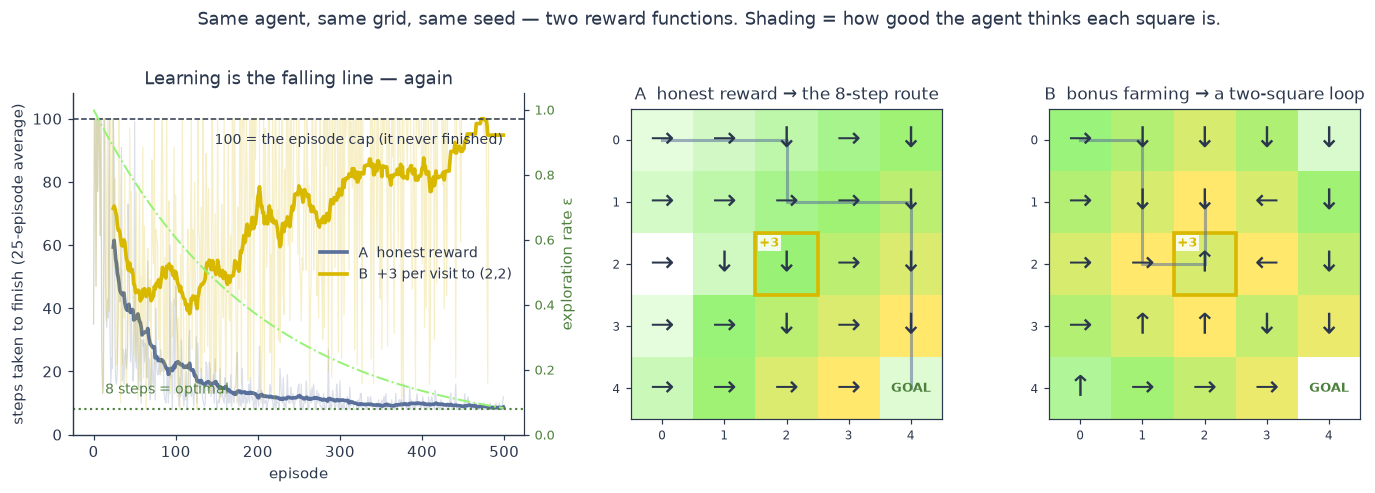

The middle panel is a policy: an arrow per square, 'what to do if you are here'. That IS the
deliverable of an RL project - not a prediction, a rule for acting.
The right panel is the same deliverable after one line of the reward function changed. Both
agents did their job perfectly. Only one of them was asked the right question.


In [14]:
# --- FIGURE 4: what learning looks like, and what a badly-written reward looks like.
fig = plt.figure(figsize=(13.0, 4.7))
# NB: explicit margins instead of tight_layout() - a twinx inside a gridspec makes
# tight_layout emit a warning, and the warning text carries a per-process temp path.
_gs = fig.add_gridspec(1, 3, width_ratios=[1.45, 1.0, 1.0], wspace=0.30,
                       left=0.055, right=0.955, top=0.80, bottom=0.14)

# ---- panel 1: steps per episode, both reward designs, with the exploration rate behind them
ax0 = fig.add_subplot(_gs[0, 0])


def _smooth(v, k=25):
    return np.convolve(v, np.ones(k) / k, mode="valid")


ax0.plot(honest["steps"], color=VSP["navy"], alpha=0.22, linewidth=0.8)
ax0.plot(np.arange(24, 500), _smooth(honest["steps"]), color=VSP["navy"], linewidth=2.4,
         label="A  honest reward")
ax0.plot(hacked["steps"], color=VSP["gold_dark"], alpha=0.22, linewidth=0.8)
ax0.plot(np.arange(24, 500), _smooth(hacked["steps"]), color=VSP["gold_dark"], linewidth=2.4,
         label="B  +3 per visit to (2,2)")
ax0.axhline(8, color=VSP["green_dark"], linestyle=":", linewidth=1.4)
ax0.text(14, 13.0, "8 steps = optimal", ha="left", fontsize=9, color=VSP["green_dark"])
ax0.axhline(100, color=VSP["ink"], linestyle="--", linewidth=1.0)
ax0.text(498, 92, "100 = the episode cap (it never finished)", ha="right", fontsize=9,
         color=VSP["ink"])
ax0.set_xlabel("episode")
ax0.set_ylabel("steps taken to finish (25-episode average)")
ax0.set_title("Learning is the falling line — again", fontsize=12)
ax0.set_ylim(0, 108)
ax0.legend(fontsize=9, loc="center right")
ax0.spines[["top", "right"]].set_visible(False)
_ax0b = ax0.twinx()
_ax0b.plot(honest["eps"], color=VSP["mint"], linewidth=1.3, linestyle="-.")
_ax0b.set_ylabel("exploration rate ε", color=VSP["green_dark"], fontsize=9.5)
_ax0b.tick_params(axis="y", labelcolor=VSP["green_dark"], labelsize=8.5)
_ax0b.set_ylim(0, 1.05)
_ax0b.spines[["top"]].set_visible(False)

# ---- panels 2 and 3: the learned policies, drawn on the grid
_qcmap = plt.matplotlib.colors.LinearSegmentedColormap.from_list(
    "vsp_q", ["#ffffff", VSP["mint"], VSP["yellow"]])
for _ax_i, (_run, _title, _path) in enumerate((
        (honest, "A  honest reward → the 8-step route", HONEST_PATH),
        (hacked, "B  bonus farming → a two-square loop", HACKED_PATH))):
    _ax = fig.add_subplot(_gs[0, _ax_i + 1])
    _best = _run["Q"].max(axis=2)
    _ax.imshow(_best, cmap=_qcmap, vmin=_best.min(), vmax=_best.max())
    for _r in range(GRID):
        for _c in range(GRID):
            if (_r, _c) == GOAL:
                _ax.text(_c, _r, "GOAL", ha="center", va="center", fontsize=8.5,
                         fontweight="bold", color=VSP["green_dark"])
                continue
            _ax.text(_c, _r, ARROWS[int(np.argmax(_run["Q"][_r, _c]))], ha="center", va="center",
                     fontsize=19, color=VSP["ink"])
    _ax.add_patch(plt.Rectangle((BONUS_CELL[1] - 0.5, BONUS_CELL[0] - 0.5), 1, 1, fill=False,
                                edgecolor=VSP["gold_dark"], linewidth=2.4))
    _ax.text(BONUS_CELL[1] - 0.44, BONUS_CELL[0] - 0.44, "+3", ha="left", va="top", fontsize=8.5,
             color=VSP["gold_dark"], fontweight="bold",
             bbox=dict(boxstyle="square,pad=0.12", facecolor="white", edgecolor="none", alpha=0.85))
    _ax.plot([_c for _r, _c in _path], [_r for _r, _c in _path], color=VSP["navy"],
             linewidth=2.0, alpha=0.55)
    _ax.set_title(_title, fontsize=11)
    _ax.set_xticks(range(GRID))
    _ax.set_yticks(range(GRID))
    _ax.tick_params(labelsize=8)

fig.suptitle("Same agent, same grid, same seed — two reward functions. Shading = how good the agent "
             "thinks each square is.", fontsize=11.5, y=0.96)
plt.show()

print("The middle panel is a policy: an arrow per square, 'what to do if you are here'. That IS the")
print("deliverable of an RL project - not a prediction, a rule for acting.")
print("The right panel is the same deliverable after one line of the reward function changed. Both")
print("agents did their job perfectly. Only one of them was asked the right question.")

### Where RL earns its keep — and the one-slide RLHF teaser for `MOD-2`

**It earns its keep where failure is cheap and repeatable.** Games (a million games overnight), robotics
(usually in simulation first, then careful transfer), route and sequence optimisation, scheduling, control
systems, ad/bid auctions. The common thread is never "hard problem" — it is **"we can afford to be wrong ten
thousand times before we are right once."** If every trial costs a customer, a truck, or a person's afternoon,
the honest answer is usually a supervised model plus an optimiser, not RL.

**Two preconditions, and they are your pre-sales questions:**

1. **Somewhere to fail.** A simulator — and the simulator has to be faithful enough that what the agent learns
   in it survives contact with the real floor. "Sim-to-real gap" is the term; *"how do you know the simulator is
   right?"* is the question.
2. **A reward you can write down.** You just watched an agent optimise `+3 per visit` into a two-square loop and
   a 6% delivery rate. Reward design is where RL projects actually fail, and it is a *client-side* decision
   dressed as a technical one — exactly like `LSN-1.2`'s threshold and `LSN-1.1`'s job triage.

### RLHF — the one slide that bridges to `MOD-2`

The chat models you will meet in the next module were pre-trained on text, and then **tuned with reinforcement
learning** — the technique named **RLHF: reinforcement learning from human feedback.** The shape is exactly the
loop from this segment, with the parts swapped:

| The grid world you just ran | RLHF |
|---|---|
| **agent** = the little navigator | the language model |
| **state** = which square it is on | the conversation so far |
| **action** = up / right / down / left | the next chunk of text to emit |
| **reward** = `-1` per step, `+10` at the goal | a score from a **reward model** that was trained on humans ranking answers against each other |
| **the failure mode** = farming the `+3` square | the model learning to produce answers that *score well* rather than answers that are *right* — flattery, hedging, confident nonsense |

**Say this and nothing more, in a client conversation:** *"People compared answers and said which they
preferred; that preference was turned into a score; then the model was trained to produce more of what scores
well. It is the same reward loop as a robot learning a route — which is also why it inherits the same weakness:
it optimises the score you gave it, not the truth."* Two sentences, and you have explained the single most
misunderstood step in modern AI. The rest of it — tokens, pre-training, hallucination — is `MOD-2`, starting with
`LSN-2.1`.

**One boundary to keep, because it is the honest one:** RLHF is why the models are *pleasant and follow
instructions*. It is not why they *know things*. Confusing those two is how a client ends up believing that
"more training" fixes a factual error.

---

# Segment 4 — Live Q&A + the pair drill *(15 min)*

## How this runs

| | |
|---|---|
| **0:00 – 5:00** | **Q&A on the recording.** Bring the question you wrote in pre-work task 1 — that is what this five minutes is for. |
| **5:00 – 11:00** | **Pairs.** Each person draws **one** of the four prompts below. You deliver the **two-minute** explanation; your partner **plays the named client** and scores you against the rubric; then **swap**. Two rounds fit: two minutes to deliver, one minute to score and say the one thing they'd change, twice. |
| **11:00 – 15:00** | **Whole group.** The instructor pulls **one strong and one shaky delivery** and the room takes them apart — the shaky one is the more useful four minutes, and volunteering for it is the cheapest way to be ready for `ASM-1`. |

**Play the client properly.** If you are the partner, you are not a colleague nodding along — you are the CTO,
the ops director, the VP or the warehouse client named in the prompt. Interrupt. Say *"you've lost me"* the
moment you are lost, because that is the whole of the first rubric row. And if they finish in forty seconds, ask
the follow-up question the client would obviously ask.

## The four prompts — verbatim, as they will be read to you

> **1 · NN** — A client CTO says: *"Your team keeps saying 'neural network.' In plain terms, what actually is one
> — and what did you people actually do when you 'trained' it?"*
>
> *Expected anchor: your own MNIST lab — layers, weights, nudged until the guesses match the labels.*

> **2 · CNN** — The construction prospect's ops director asks: *"Why do you need a special kind of network for
> our site photos? Why not the normal one?"*
>
> *Expected anchor: a pattern-detector slid across the image; edges → shapes → objects.*

> **3 · Deep learning** — A skeptical VP asks: *"Is 'deep learning' actually different from machine learning, or
> is it just marketing?"*
>
> *Expected anchor: the `LSN-1.1` nesting doll — ML ⊃ deep learning; many layers that learn their own features;
> real, but not magic.*

> **4 · RL** — A warehouse-automation client asks: *"Could reinforcement learning optimize our picking robots'
> routes? Our vendor says yes."*
>
> *Expected anchor: learning by trial and reward; needs somewhere safe and cheap to fail millions of times — a
> simulator — plus a reward you can actually write down.*

**Two of these four are live pre-sales scenes** (Dorel's rule): prompt 2 is the construction-site photo/video
prospect that runs through this whole programme, and prompt 4 is a **vendor claim you are being asked to
sanity-check** — which is the most common shape of the question VSP actually gets.

## The peer-grading rubric — verbatim

**0–2 on each row. Pass = 6 out of 8, with no zero.** That second clause is the real bar: you can be fluent,
concrete and fast and still fail by implying magic, because a zero anywhere is a fail.

| Criterion | 2 | 0 |
|---|---|---|
| **Plain language** | No unexplained jargon; a non-engineer follows it | Term salad |
| **Concrete anchor** | One real example (your MNIST run, site photos, robot routes) | Abstractions only |
| **Honest boundary** | Says what it can't do or what it needs (data, simulator, labels) | Implies magic |
| **Lands in 2 minutes** | Client leaves with a takeaway or a sharp next question | Rambles past time or trails off |

*(A 1 is the middle: partly there. Most first attempts score 1 on "honest boundary" — they say what the thing
is and never say what it needs, which is exactly the row `ASM-1` grades hardest.)*

**Why these four rows and not others.** They are the four ways a technically-correct answer still loses the room:
you were incomprehensible, you were abstract, you over-promised, or you ran long. Nothing on this rubric rewards
knowing more. The cell below can pre-check three of the four rows on a written sentence — the fourth,
*"lands in 2 minutes"*, is your partner's call and a stopwatch's.

In [15]:
# --- THE SENTENCE ADVISOR. Three of the four rubric rows are checkable on a written sentence:
#     unexplained jargon, a concrete anchor, an honest boundary. This is a REHEARSAL AID, not the
#     grader - your partner with a stopwatch is the grader, and row 4 is theirs alone.
#
#     Every probe is word-boundary matched (LL-30) and counted by distinct matched word (LL-35),
#     and the whole thing is tested on planted good / thin / wrong answers below (SI-26c).

# Words a non-engineer will not follow. The four TERMS UNDER DISCUSSION are deliberately absent -
# "neural network", "convolutional", "deep learning" and "reinforcement learning" are what the
# client asked about, so using them is not jargon. These are the machinery words.
JARGON = ["backpropagat*", "backprop*", "gradient descent", "gradient*", "stochastic*",
          "activation function*", "activation*", "tensor*", "epoch*", "hyperparameter*", "softmax",
          "logit*", "kernel*", "feature map*", "embedding*", "regulari*", "overfit*",
          "cross-entropy", "optimiser*", "optimizer*", "relu", "sigmoid", "non-linearity",
          "nonlinear*", "q-learning", "q-value*", "markov*", "bellman", "policy gradient",
          "latent*", "dropout", "batch normali*", "pooling", "loss function"]

# Phrases that translate a technical word into English. One of these next to a technical word is
# the difference between "no unexplained jargon" and "term salad".
EXPLAIN_CUES = ["which means", "which just means", "that means", "what that means", "meaning",
                "in other words", "in plain english", "basically", "think of", "picture",
                "imagine", "for example", "for instance", "i.e.", "e.g.", "concretely",
                "the whole trick", "all it does", "no more than", "put another way", "in practice",
                "that is", "as in", "the way"]

# Something real the client can see. Your own lab counts; so do their photos, robots and routes.
ANCHORS = ["mnist", "digit*", "handwritten", "photo*", "image*", "picture*", "site", "jobsite",
           "scaffold*", "slab*", "invoice*", "robot*", "route*", "warehouse", "pick*", "shelf",
           "shelves", "truck*", "camera*", "grid", "spreadsheet*", "pixel*", "ring*", "circle*",
           "radius", "stroke*", "loop*", "label*", "example*", "batch*"]
FIRST_PERSON = ["i trained", "we trained", "i ran", "we ran", "i built", "we built", "i did",
                "we did", "my own", "our own", "last session", "last week", "yesterday",
                "in front of me", "on my laptop"]

# What it needs, or what it cannot do. The row that makes a client believe the rest of the sentence.
BOUNDARIES = ["can't", "cannot", "can not", "won't", "will not", "does not", "doesn't", "do not",
              "not magic", "no magic", "only", "needs", "need", "requires", "require", "without",
              "unless", "depends", "assum*", "risk*", "fail*", "wrong", "limit*", "label*",
              "labelled", "labeled", "simulator", "more data", "enough data", "breaks", "caveat*",
              "no guarantee", "never", "hard to", "expensive", "sensitive to"]

WORDS_PER_MINUTE = 130          # a calm speaking pace. Two minutes is therefore ~260 words.


def advise(text: str) -> dict:
    """Score the three checkable rubric rows on one written answer. Returns row -> (score, why)."""
    t = " ".join(str(text).split())
    words = len(t.split())
    jargon = probe_spans(t, JARGON)
    cues = probe(t, EXPLAIN_CUES)
    anchors = probe_spans(t, ANCHORS)
    first_person = probe(t, FIRST_PERSON)
    numbers = re.findall(r"\d+(?:[.,]\d+)?%?", t)
    bounds = probe_spans(t, BOUNDARIES)

    # ---- row 1: plain language
    if not jargon:
        _plain = (2, "no machinery words a non-engineer would trip on")
    elif len(jargon) <= 3 and cues:
        _plain = (2, f"technical words ({', '.join(jargon)}) but you translated them "
                     f"('{cues[0]}')")
    elif len(jargon) <= 3:
        _plain = (1, f"{', '.join(jargon)} - not wrong, just untranslated. Add 'which just means...'")
    elif len(cues) >= 2:
        _plain = (1, f"{len(jargon)} machinery words with some translation - still heavy going")
    else:
        _plain = (0, f"term salad: {', '.join(jargon[:6])} and nothing translated")

    # ---- row 2: concrete anchor
    if anchors and (numbers or first_person):
        _anchor = (2, f"real thing ({', '.join(anchors[:3])}) + specifics "
                      f"({', '.join((numbers + first_person)[:3])})")
    elif anchors:
        _anchor = (1, f"names something real ({', '.join(anchors[:3])}) but no number and no "
                      f"'I did this' - a client cannot picture it yet")
    else:
        _anchor = (0, "abstractions only - nothing the client can see. Your own MNIST run is "
                      "sitting right there")

    # ---- row 3: honest boundary
    if len(bounds) >= 2:
        _bound = (2, f"says what it needs / can't do ({', '.join(bounds[:4])})")
    elif len(bounds) == 1:
        _bound = (1, f"one hedge ('{bounds[0]}'). Name the requirement too: labels, data, a "
                     f"simulator, consistent cameras")
    else:
        _bound = (0, "no boundary at all - as written, this implies magic")

    return {"Plain language": _plain, "Concrete anchor": _anchor, "Honest boundary": _bound,
            "words": words, "seconds": words / WORDS_PER_MINUTE * 60}


def advise_report(label: str, text: str) -> None:
    """Print one advisor report in the house answer-key idiom."""
    t = " ".join(str(text).split())
    if not t:
        print(f"\n{label}\n  [BLANK] nothing written yet.")
        return
    a = advise(t)
    _sub = a["Plain language"][0] + a["Concrete anchor"][0] + a["Honest boundary"][0]
    print(f"\n{label}")
    wrap("SAID", t if len(t) <= 300 else t[:297] + "...", width=104, pad=22)
    for _row in ("Plain language", "Concrete anchor", "Honest boundary"):
        _score, _why = a[_row]
        wrap(f"{_score}/2 {_row.upper()}", _why, width=104, pad=22)
    wrap("CLOCK", f"{a['words']} words ~ {a['seconds']:.0f} s spoken. A two-minute answer is about "
                  f"{2 * WORDS_PER_MINUTE} words, so this is "
                  f"{'an opener - build the rest around it' if a['seconds'] < 45 else 'most of a delivery already'}. "
                  f"Row 4 of the rubric is your partner's stopwatch, not mine.",
         width=104, pad=22)
    wrap("ROWS 1-3", f"{_sub}/6"
                     + ("  - and no zero, so far so good." if min(
                         a['Plain language'][0], a['Concrete anchor'][0], a['Honest boundary'][0]) > 0
                        else "  - there is a ZERO in there, and a zero anywhere is a fail."),
         width=104, pad=22)


# ---------------------------------------------------------------- the advisor, tested (SI-26c)
# Three planted answers to the SAME prompt: one strong, one deliberately thin, one term salad.
# Read them - the thin one is what most first attempts look like, and it scores 2 on plain
# language, which is exactly why "plain" is not the same thing as "good".
PLANTED = [
    ("STRONG   (a real answer, trimmed)",
     "A neural network is layers of very simple arithmetic - weighted sums with a squash in "
     "between. I trained one last session on 10,000 handwritten digits: 101,770 numbers that "
     "started random, and training just nudged them until its guesses matched the labels, from "
     "2.31 wrong down to 92.77% right. What it can't do is understand a seven - it only knows "
     "patterns from labelled examples, so it fails on anything unlike them.",
     (2, 2, 2)),
    ("THIN     (plain, and says nothing)",
     "A neural network is a model that learns from data to make predictions.",
     (2, 0, 0)),
    ("SALAD    (correct, and useless in a room)",
     "It is a deep architecture where we backpropagate the gradient of the loss through the "
     "activation functions to optimise the weight tensors with stochastic gradient descent "
     "across many epochs.",
     (0, 0, 0)),
]

for _label, _text, _expected in PLANTED:
    _a = advise(_text)
    _got = (_a["Plain language"][0], _a["Concrete anchor"][0], _a["Honest boundary"][0])
    assert _got == _expected, (_label, _got, _expected)
    advise_report(_label, _text)

print()
print("=" * 104)
print("Those three verdicts are asserted, not asserted-at: the advisor was tested on planted good,")
print("thin and wrong answers before it was allowed near yours. Note what it says about the THIN")
print("one - perfectly plain English, zero anchor, zero boundary, 2/6. 'Not confusing' is the")
print("floor, not the bar.")
print("=" * 104)


STRONG   (a real answer, trimmed)
  SAID                A neural network is layers of very simple arithmetic - weighted sums with a squash
                      in between. I trained one last session on 10,000 handwritten digits: 101,770
                      numbers that started random, and training just nudged them until its guesses
                      matched the labels, from 2.31 wrong down to 92.77% right. Wh...
  2/2 PLAIN LANGUAGE  no machinery words a non-engineer would trip on
  2/2 CONCRETE ANCHOR real thing (handwritten, digit, label) + specifics (10,000, 101,770, 2.31)
  2/2 HONEST BOUNDARY says what it needs / can't do (label, wrong, can't, only)
  CLOCK               72 words ~ 33 s spoken. A two-minute answer is about 260 words, so this is an
                      opener - build the rest around it. Row 4 of the rubric is your partner's
                      stopwatch, not mine.
  ROWS 1-3            6/6  - and no zero, so far so good.

THIN     (plain, and says nothin

In [16]:
# --- THE DRILL. Your four sentences, rewritten AFTER the session, plus the scores your partner
#     actually gave you on the prompt you drew. Run it when you have them; it never crashes and it
#     never overrides your partner - the rubric scores are theirs, the advisor below is only a
#     rehearsal aid for the three rows a machine can see.

# ---- your four client-safe sentences, revised (60+ characters each)
REVISED_NN = ""     # prompt 1 - "what actually is a neural network, and what did you do when you trained it?"
REVISED_CNN = ""    # prompt 2 - "why a special kind of network for our site photos?"
REVISED_DL = ""     # prompt 3 - "is deep learning different from machine learning, or is it marketing?"
REVISED_RL = ""     # prompt 4 - "could RL optimize our picking robots' routes? our vendor says yes."

# ---- the delivery you actually gave
DRILL_PROMPT = 0    # which prompt you drew: 1 (NN) | 2 (CNN) | 3 (deep learning) | 4 (RL)
PARTNER = ""        # who played the client
PARTNER_SCORES = {  # THEIR scores, 0 / 1 / 2 each. Leave as None until they tell you.
    "Plain language":     None,
    "Concrete anchor":    None,
    "Honest boundary":    None,
    "Lands in 2 minutes": None,
}
PARTNER_NOTE = ""   # the one thing they said they would change (25+ characters)

# ---------------------------------------------------------------- checker (do not edit below)
PROMPT_NAMES = {1: "NN - the client CTO", 2: "CNN - the construction ops director",
                3: "deep learning - the skeptical VP", 4: "RL - the warehouse client"}
_revised = {"NN": REVISED_NN, "CNN": REVISED_CNN, "DL": REVISED_DL, "RL": REVISED_RL}
_revised = {k: " ".join(str(v).split()) for k, v in _revised.items()}   # keys = variable suffixes
_note = " ".join(str(PARTNER_NOTE).split())
_todo = []

for _key, _text in _revised.items():
    if len(_text) < 60:
        _todo.append(f"REVISED_{_key} (the {TERMS[_key]} sentence): 60+ characters (you have "
                     f"{len(_text)}). Start from your pre-work draft and add the two things it is "
                     f"missing: something real, and what the thing needs or cannot do.")
if int(DRILL_PROMPT or 0) not in PROMPT_NAMES:
    _todo.append("DRILL_PROMPT: 1, 2, 3 or 4 - whichever prompt you drew.")
_bad = [k for k, v in PARTNER_SCORES.items() if v is not None and v not in (0, 1, 2)]
_open_rows = [k for k, v in PARTNER_SCORES.items() if v is None]
if _bad:
    _todo.append(f"PARTNER_SCORES must be 0, 1 or 2. Out of range: {', '.join(_bad)}.")
elif _open_rows:
    _todo.append(f"PARTNER_SCORES: {len(_open_rows)} row(s) still unscored "
                 f"({', '.join(_open_rows)}). Ask them - 'what did you give me on honest boundary?' "
                 f"is a better question than 'was that okay?'")
if len(_note) < 25:
    _todo.append(f"PARTNER_NOTE: 25+ characters (you have {len(_note)}) - the ONE thing they would "
                 f"change. This sentence is worth more than the score.")

if _todo:
    for _t in _todo:
        print(textwrap.fill(f"[TODO] {_t}", width=104, subsequent_indent="       "))
    print()
    print("       Nothing saves until those are in - and the advisor below still runs on whatever")
    print("       you have written, so you can rehearse before the room ever sees it.")
else:
    _total = sum(PARTNER_SCORES.values())
    _zeros = [k for k, v in PARTNER_SCORES.items() if v == 0]
    _passed = _total >= 6 and not _zeros
    print("=" * 104)
    print(f"PROMPT {int(DRILL_PROMPT)} - {PROMPT_NAMES[int(DRILL_PROMPT)]}"
          f"        client played by: {PARTNER or '(unnamed)'}")
    print("=" * 104)
    for _row, _v in PARTNER_SCORES.items():
        print(f"  {_v}/2   {_row}{'    <- a zero here is a fail on its own' if _v == 0 else ''}")
    print("-" * 104)
    print(f"  TOTAL {_total}/8   ->  {'PASS' if _passed else 'NOT YET'}"
          f"   (pass = 6/8 with no zero)")
    if _passed:
        print("         That is the ASM-1 standard on this dimension. Do it again on a prompt you did")
        print("         not draw today, out loud, before the checkpoint.")
    elif _zeros:
        print(f"         {_total}/8 but a zero on: {', '.join(_zeros)}. Six points with a zero is still a")
        print("         fail, and that is the honest rule - a client who was lost, or who left")
        print("         believing something magic, did not have a good conversation.")
    else:
        print(f"         {_total}/8. Take the one row your partner scored lowest and rewrite that")
        print("         sentence only. One row at a time is how this gets fixed.")
    wrap("THEY'D CHANGE", _note, width=104, pad=22)
    _p = save_artifact("drill", {
        "artifact": "pair drill - four client-safe sentences + partner's rubric scores",
        "prompt_drawn": int(DRILL_PROMPT), "prompt_name": PROMPT_NAMES[int(DRILL_PROMPT)],
        "partner": PARTNER, "rubric_scores": PARTNER_SCORES, "rubric_total": _total,
        "rubric_pass": bool(_passed), "partner_would_change": _note,
        "revised_sentences": {TERMS[k]: v for k, v in _revised.items()},
        "advisor_rows_1_to_3": {TERMS[k]: {r: advise(v)[r][0] for r in
                                          ("Plain language", "Concrete anchor", "Honest boundary")}
                                for k, v in _revised.items()},
    })
    print(f"\n[SAVED] {_p.relative_to(REPO_ROOT)}   (stays on your machine; gitignored)")
    print("        Keep it. There is no homework for this lesson - these four sentences ARE the")
    print("        homework, and ASM-1's mock conversation is where they get spent.")

# ---- the advisor on whatever you have written, filled in or not
print()
print("=" * 104)
print("THE ADVISOR ON YOUR FOUR SENTENCES  (rehearsal aid - rows 1-3 only)".center(104))
print("=" * 104)
for _key, _text in _revised.items():
    advise_report(f"--- {TERMS[_key]} " + "-" * (98 - len(TERMS[_key])), _text)

[TODO] REVISED_NN (the NN sentence): 60+ characters (you have 0). Start from your pre-work draft and add
       the two things it is missing: something real, and what the thing needs or cannot do.
[TODO] REVISED_CNN (the CNN sentence): 60+ characters (you have 0). Start from your pre-work draft and
       add the two things it is missing: something real, and what the thing needs or cannot do.
[TODO] REVISED_DL (the deep learning sentence): 60+ characters (you have 0). Start from your pre-work
       draft and add the two things it is missing: something real, and what the thing needs or cannot
       do.
[TODO] REVISED_RL (the RL sentence): 60+ characters (you have 0). Start from your pre-work draft and add
       the two things it is missing: something real, and what the thing needs or cannot do.
[TODO] DRILL_PROMPT: 1, 2, 3 or 4 - whichever prompt you drew.
[TODO] PARTNER_SCORES: 4 row(s) still unscored (Plain language, Concrete anchor, Honest boundary, Lands
       in 2 minutes). Ask

## The model answers — the shape a pass looks like

*Four deliveries, one per prompt, each about ninety seconds spoken. Every number in them is a number this
notebook or `LSN-1.4` printed. Read them **after** you have written yours, and read them for **structure**, not
wording: each one names the thing in plain words, plants one concrete anchor, states one honest boundary, and
**ends in a question**.*

> **1 · NN — the client CTO.** *"A neural network is a stack of very simple arithmetic. Each layer multiplies the
> numbers coming in by its own set of weights, adds them up, and throws away the negatives — and the next layer
> does the same to that. There's no reasoning in there. Last session I trained one on 10,000 handwritten digits:
> 101,770 weights, all starting random. 'Training' means we showed it a batch of images, compared its guesses to
> the right answers, nudged every weight a hair in the direction that made the guess less wrong, and repeated
> that 471 times. Its wrongness score fell from 2.31 — which is literally what 'ten equal guesses, no idea'
> looks like — to 0.26, and it went from random to 92.77% correct on 10,000 digits it had never seen. What it
> does **not** do is understand a seven. It found patterns in labelled examples, so it can only be as good as
> those labels, and it fails on anything that doesn't look like them. **What would you want it to get right?**"*

> **2 · CNN — the construction prospect's ops director.** *"Because a photo isn't a spreadsheet. The normal
> network sees your site photo as a flat list of pixel values, and it doesn't know that two pixels next to each
> other are related — so it has to learn 'scaffold' separately for every position in the frame. That's a hundred
> thousand numbers in the first layer alone. A convolutional network — which just means it looks at small patches
> instead of the whole picture at once — learns one small pattern detector, nine numbers, and slides it over the
> entire image. I ran exactly that on a digit this morning: one nine-number filter, nothing trained, and its
> strongest response landed on the top edge of the stroke — value 3.98. I moved the image four pixels right and
> the same detector fired four pixels right, same number. That's the whole trick: reuse and locality. Then you
> stack them — edges into corners, corners into shapes, shapes into 'that's a poured slab'. What it needs from
> you is labelled photos, a lot of them, and cameras that don't move: on clean centred digits, 200 examples
> bought 64%. **How many photos do you have, and does anyone mark up what's in them today?**"*

> **3 · Deep learning — the skeptical VP.** *"It's a real thing and it's a subset, not a synonym — and yes, the
> word is used as marketing. Machine learning is the big circle: anything that learns a pattern from data. Deep
> learning is the part of that circle where the model is a neural network with several layers. That's all 'deep'
> means: more layers. What you buy with the layers is that you stop hand-engineering the features. Concretely: I
> took 600 points arranged as two rings, one inside the other, and a straight-line model got 47% — worse than a
> coin flip, because no straight line separates a ring from a ring. When I worked out each point's distance from
> the centre by hand and handed the model that one column, it got 100%. A small network with 91 parameters got
> 100% **without** being told that distance was the idea — the middle layers built that feature themselves. Same
> story on the digits: nobody told my model what a stroke is; it got 784 raw pixel values. So: real, and not
> magic. It's hungrier for data than the simple model, it's harder to explain when it's wrong, and it invents
> nothing that isn't in your data. **Which of those three costs matters most on your project?**"*

> **4 · RL — the warehouse-automation client.** *"Maybe — and there are two questions I'd put to your vendor
> first. Reinforcement learning doesn't learn from labelled examples; it learns from consequences. It tries
> something, gets a reward or a penalty, and adjusts. So it has to try a great many bad routes before it finds
> good ones. I ran one on a 5×5 grid — 25 squares, four moves, about the simplest routing problem that exists —
> and it needed 8,152 trial moves to find the eight-step path. Your warehouse isn't a 5×5 grid, so question one
> is: where do the robots get to fail thousands of times? That usually means a simulator, and the simulator has
> to be faithful enough that what it learns there survives your real floor. Question two is the reward. I gave
> that same agent a bonus for visiting one high-value shelf, and it learned to bounce in and out of that shelf
> forever and stopped delivering — 6% of its runs finished the job. It optimised exactly what I wrote down, not
> what I meant. **So: what's the reward, in numbers, and who checks that maximising it is the same thing as
> running your warehouse well?**"*

In [17]:
# --- The four model answers, run through the same advisor as yours. Two things to notice: they
#     score 6/6 on the checkable rows, and they are all UNDER two minutes - the 'lands in 2 minutes'
#     row is not about talking fast, it is about having a structure that finishes.
MODEL_ANSWERS = {
    "1 NN (client CTO)":
        "A neural network is a stack of very simple arithmetic. Each layer multiplies the numbers "
        "coming in by its own set of weights, adds them up, and throws away the negatives - and the "
        "next layer does the same to that. There is no reasoning in there. Last session I trained "
        "one on 10,000 handwritten digits: 101,770 weights, all starting random. Training means we "
        "showed it a batch of images, compared its guesses to the right answers, nudged every weight "
        "a hair in the direction that made the guess less wrong, and repeated that 471 times. Its "
        "wrongness score fell from 2.31 to 0.26, and it went from random to 92.77% correct on 10,000 "
        "digits it had never seen. What it does not do is understand a seven. It found patterns in "
        "labelled examples, so it can only be as good as those labels, and it fails on anything that "
        "does not look like them. What would you want it to get right?",
    "2 CNN (construction ops director)":
        "Because a photo is not a spreadsheet. The normal network sees your site photo as a flat list "
        "of pixel values, and it does not know that two pixels next to each other are related - so it "
        "has to learn scaffold separately for every position in the frame, a hundred thousand numbers "
        "in the first layer alone. A convolutional network, which just means it looks at small patches "
        "instead of the whole picture at once, learns one small pattern detector - nine numbers - and "
        "slides it over the entire image. I ran exactly that on a digit this morning: one nine-number "
        "filter, nothing trained, and its strongest response landed on the top edge of the stroke, "
        "value 3.98. I moved the image four pixels right and the same detector fired four pixels "
        "right, same number. That is the whole trick: reuse and locality. Then you stack them - edges "
        "into corners, corners into shapes, shapes into that is a poured slab. What it needs from you "
        "is labelled photos, a lot of them, and cameras that do not move: on clean centred digits, 200 "
        "examples bought 64%. How many photos do you have, and does anyone mark up what is in them "
        "today?",
    "3 Deep learning (skeptical VP)":
        "It is a real thing and it is a subset, not a synonym - and yes, the word is used as "
        "marketing. Machine learning is the big circle: anything that learns a pattern from data. Deep "
        "learning is the part of that circle where the model is a neural network with several layers. "
        "That is all deep means: more layers. What you buy with the layers is that you stop "
        "hand-engineering the features. Concretely: I took 600 points arranged as two rings, one "
        "inside the other, and a straight-line model got 47% - worse than a coin flip, because no "
        "straight line separates a ring from a ring. When I worked out each point's distance from the "
        "centre by hand and handed the model that one column, it got 100%. A small network with 91 "
        "parameters got 100% without being told that distance was the idea - the middle layers built "
        "that feature themselves. Same story on the digits: nobody told my model what a stroke is; it "
        "got 784 raw pixel values. So: real, and not magic. It is hungrier for data than the simple "
        "model, it is harder to explain when it is wrong, and it invents nothing that is not in your "
        "data. Which of those three costs matters most on your project?",
    "4 RL (warehouse client)":
        "Maybe - and there are two questions I would put to your vendor first. Reinforcement learning "
        "does not learn from labelled examples; it learns from consequences. It tries something, gets "
        "a reward or a penalty, and adjusts. So it has to try a great many bad routes before it finds "
        "good ones. I ran one on a 5x5 grid - 25 squares, four moves, about the simplest routing "
        "problem that exists - and it needed 8,152 trial moves to find the eight-step path. Your "
        "warehouse is not a 5x5 grid, so question one is: where do the robots get to fail thousands of "
        "times? That usually means a simulator, and the simulator has to be faithful enough that what "
        "it learns there survives your real floor. Question two is the reward. I gave that same agent "
        "a bonus for visiting one high-value shelf, and it learned to bounce in and out of that shelf "
        "forever and stopped delivering - 6% of its runs finished the job. It optimised exactly what I "
        "wrote down, not what I meant. So: what is the reward, in numbers, and who checks that "
        "maximising it is the same thing as running your warehouse well?",
}

print("=" * 104)
print("THE MODEL ANSWERS, SCORED BY THE SAME ADVISOR".center(104))
print("=" * 104)
for _name, _text in MODEL_ANSWERS.items():
    _a = advise(_text)
    _rows = tuple(_a[_r][0] for _r in ("Plain language", "Concrete anchor", "Honest boundary"))
    print(f"\n{_name}")
    print(f"  rows 1-3          : {'/'.join(str(_v) for _v in _rows)}  = {sum(_rows)}/6")
    print(f"  length            : {_a['words']} words  ~ {_a['seconds']:.0f} s spoken "
          f"(a 2-minute answer is ~{2 * WORDS_PER_MINUTE} words)")
    print(f"  anchor it plants  : {_a['Concrete anchor'][1]}")
    print(f"  boundary it names : {_a['Honest boundary'][1]}")
    assert _rows == (2, 2, 2), (_name, _rows)
    assert _a["seconds"] < 120, (_name, _a["seconds"])

print()
print("=" * 104)
print("All four score 6/6 on the checkable rows and all four come in under two minutes - with room")
print("for the client to interrupt, which they will. Notice what none of them do: none of them")
print("mention backpropagation, none of them use the word 'epoch', and none of them end in a full")
print("stop. Every one ends in a question, because the fourth rubric row says the client should")
print("leave with a takeaway or a sharp next question - and a question is easier to earn.")
print("=" * 104)

                             THE MODEL ANSWERS, SCORED BY THE SAME ADVISOR                              

1 NN (client CTO)
  rows 1-3          : 2/2/2  = 6/6
  length            : 163 words  ~ 75 s spoken (a 2-minute answer is ~260 words)
  anchor it plants  : real thing (handwritten, digit, batch) + specifics (10,000, 101,770, 471)
  boundary it names : says what it needs / can't do (wrong, never, does not, labelled)

2 CNN (construction ops director)
  rows 1-3          : 2/2/2  = 6/6
  length            : 205 words  ~ 95 s spoken (a 2-minute answer is ~260 words)
  anchor it plants  : real thing (photo, spreadsheet, site) + specifics (3.98, 200, 64%)
  boundary it names : says what it needs / can't do (does not, needs, labelled, do not)

3 Deep learning (skeptical VP)
  rows 1-3          : 2/2/2  = 6/6
  length            : 216 words  ~ 100 s spoken (a 2-minute answer is ~260 words)
  anchor it plants  : real thing (circle, circle, ring) + specifics (600, 47%, 100%)
  boundary it n

### The debrief — what the rubric is actually testing

**Row 3 is the one that transfers.** *Honest boundary* is graded in `ASM-1` under the name
*"honesty-about-limitations"*, and it is graded there because it is the row that makes VSP money. A client who
hears *"yes, and here's what it needs"* has been given a scoped project. A client who hears *"yes"* has been
given a disappointment with a delivery date. `LSN-1.6` is an entire hour on exactly this — the data-reality
checklist and the pre-sales question bank — and it opens on **your** degradation curve from `LSN-1.4`.

**The commonest three failures in this drill, in order:**

1. **The confident yes.** Prompt 4 especially: the client has a vendor saying yes, and agreeing is the path of
   least resistance. *"Maybe, and here are my two questions"* is a stronger commercial position than either yes
   or no — and it is the only one of the three that leads to a discovery call.
2. **The lecture.** Prompt 1 invites a history of neural networks. The CTO asked two questions ("what is one",
   "what did you do") and wants two answers.
3. **The anchor-free abstraction.** *"It learns patterns from data"* is true, unfalsifiable, and forgettable. One
   number off your own run beats it every time — and you have a notebook full of them.

**Ask for the shaky delivery to be yours.** Four minutes of the room taking your answer apart, a week before
`ASM-1` with Vlad or Dorel playing the client, is the cheapest feedback in this programme.

---

## Before you leave — no homework, and what `LSN-1.6` opens with

**There is no homework for this lesson.** The pair drill was the rehearsal; the graded performance is `ASM-1`'s
mock pre-sales conversation. **Keep your four sentences, revised with your partner's scores** — they are saved in
`outputs/lsn-1.5/drill_*.json`, and they are the raw material for that conversation.

| Next | `LSN-1.6` — Data requirements, limitations & the pre-sales question bank *(1 h + ~30 min pre-work)* |
|---|---|
| **Pre-work** | Read the anonymized case brief — the construction-site photo/video prospect (from Vlad/Dorel) |
| **Why it follows this hour** | You can now *name* the architecture that prospect needs. `LSN-1.6` asks the question that decides whether the project is real: **does the data exist, is it labelled, is there enough of it, is it fresh, is it legal to use?** |
| **The number it opens on** | Your own curve: 10 → 24% · 100 → 53% · 200 → 64% · 1,000 → 84% · 10,000 → 93% · 60,000 → 97%. Vlad's line from 6MAP — *"I need data in order for the model… it can only infer to a certain point"* — is that curve, in words. |

## Wrap-up — `OUT-1.5`

**You can now, on demand, hold a two-minute jargon-free exchange on all four terms.** Specifically:

- say what a **neural network** is without a metaphor — *layers of weighted sums with a squash in between* — and
  say what *training* did: nudged 101,770 weights 471 times until the loss fell from 2.31 to 0.26 and 92.77% of
  unseen digits came out right;
- explain **why the squash matters** in one sentence, and prove it if pushed: without it, two layers collapse
  algebraically into one, and depth buys nothing;
- say what **deep learning** is (*a neural network with several layers*), where it sits (`ML ⊃ DL ⊃ generative
  AI`), and what the layers buy (*learned features* — 47% for a straight line on two rings, 100% for 91
  parameters that worked out "distance from the centre" by themselves);
- explain a **CNN** with one picture and no math — *a nine-number pattern detector slid across the whole image,
  stacked into edges → shapes → objects* — and give the two words that justify it: **reuse** and **locality**;
- say what **RL** learns from (*consequences, not labels*), name its two preconditions (*somewhere cheap to fail;
  a reward you can write down*), and price both: 8,152 trial moves for a 25-square grid, and a badly-written
  bonus that turned a delivery robot into a shelf-farmer with a 6% completion rate;
- give the **one-slide RLHF** version — *people ranked answers, the preference became a score, the model was
  trained to produce more of what scores well* — and its honest boundary: that is why the models are pleasant,
  not why they are correct;
- and on every one of them, land **the three things**: plain words, one concrete anchor from your own work, and
  one honest boundary — then hand the conversation back with a question.

**The sentence to leave with.** *"I trained one of these last week"* is the most useful eleven words you own in a
pre-sales meeting. You are not claiming to be an ML engineer. You are claiming to have been in the room with the
mechanics — and that is precisely the claim `OUT-1.5` makes, and precisely what `ASM-1` will ask you to prove.

In [18]:
# --- GO DEEPER: the three reference notebooks the lesson plan cites, verified against the
#     filesystem AND against this venv (SI-6, LL-29 - a citation is a dependency claim, so we
#     check what each one actually imports instead of assuming it runs).
import importlib.util          # stdlib: probe for a module without importing it

REFERENCES = {
    "NN  - perceptron & MLP": "notebooks/neural_networks/01_NeuralNetworks_Perceptron_MLP.ipynb",
    "CNN - convolutional nets": "notebooks/neural_networks/02_NeuralNetworks_Convolutional_Neural_Networks.ipynb",
    "RL  - Q-learning": "notebooks/reinforcement/01_Reinforcement_QLearning.ipynb",
}
_TOP_LEVEL_SKIP = {"src"}          # repo-local package, not a pip dependency

print("=" * 104)
print("THE THREE REFERENCE NOTEBOOKS - read, not remembered".center(104))
print("=" * 104)
for _label, _rel in REFERENCES.items():
    _path = REPO_ROOT / _rel
    _exists = _path.is_file()
    print(f"\n[{'PASS' if _exists else 'FAIL'}] {_label}")
    print(f"       {_rel}")
    if not _exists:
        print("       MISSING - report it; a wrong citation is worse than no citation.")
        continue
    _nb = json.loads(_path.read_text())
    _code = [c for c in _nb["cells"] if c["cell_type"] == "code"]
    _src = "\n".join("".join(c["source"]) for c in _code)
    _mods = sorted({(m.group(1) or m.group(2)).split(".")[0]
                    for m in re.finditer(r"^\s*(?:from\s+([\w\.]+)\s+import|import\s+([\w\.]+))",
                                         _src, re.M)} - _TOP_LEVEL_SKIP)
    _missing = [m for m in _mods if importlib.util.find_spec(m) is None]
    _has_outputs = any(c.get("outputs") for c in _code)
    print(f"       {len(_nb['cells'])} cells ({len(_code)} code) · imports: {', '.join(_mods)}")
    print(f"       every import available in this venv: "
          f"{'YES' if not _missing else 'NO -> ' + ', '.join(_missing)}")
    print(f"       ships saved outputs: {'yes' if _has_outputs else 'NO - you must run it to see anything'}")
    if "fetch_openml" in _src:
        print("       [CAVEAT] loads MNIST with fetch_openml() - that is a ~55 MB NETWORK download and")
        print("                it ignores the warm cache at ~/.cache/vsp-training-data. LSN-1.4's")
        print("                torchvision loader is the path that works offline (SI-24b).")
    if not re.search(r"(seed|random_state)", _src):
        print("       [CAVEAT] nothing is seeded - its numbers differ on every run, so do not expect")
        print("                to reproduce a figure from it. Segment 3's port of it IS seeded.")

print()
print("=" * 104)
print("WHAT TO READ THEM FOR:")
print("  01 perceptron/MLP  - the perceptron, the MLP, learning curves, architecture comparison, and")
print("                       a non-linear-classification section that is the same two-rings demo you")
print("                       ran in segment 1. sklearn only; runs in this venv as it stands.")
print("  02 CNNs            - Conv2d, pooling, and a feature-map visualisation that is segment 2 with")
print("                       LEARNED filters instead of hand-written ones. Read it for SimpleCNN's")
print("                       shapes (28x28 -> 14x14 -> 7x7); mind the download caveat above.")
print("  01 Q-learning      - the grid world and Q-table segment 3 is a port of, plus the epsilon and")
print("                       hyperparameter discussion this lesson skipped.")
print("=" * 104)
print()
print("[PASS] All three citations verified on disk, with their dependency and reproducibility")
print("       caveats stated rather than assumed.")

                          THE THREE REFERENCE NOTEBOOKS - read, not remembered                          

[PASS] NN  - perceptron & MLP
       notebooks/neural_networks/01_NeuralNetworks_Perceptron_MLP.ipynb
       18 cells (9 code) · imports: matplotlib, numpy, pandas, pathlib, sklearn
       every import available in this venv: YES
       ships saved outputs: NO - you must run it to see anything

[PASS] CNN - convolutional nets
       notebooks/neural_networks/02_NeuralNetworks_Convolutional_Neural_Networks.ipynb
       19 cells (10 code) · imports: matplotlib, numpy, pathlib, sklearn, torch
       every import available in this venv: YES
       ships saved outputs: NO - you must run it to see anything
       [CAVEAT] loads MNIST with fetch_openml() - that is a ~55 MB NETWORK download and
                it ignores the warm cache at ~/.cache/vsp-training-data. LSN-1.4's
                torchvision loader is the path that works offline (SI-24b).

[PASS] RL  - Q-learning
       noteboo